# Model Evaluation and Candidate Selection

This notebook evaluates candidate credit card fraud detection models on the holdout test set and cross-validation outputs. It compares Logistic Regression and Random Forest with fraud-relevant metrics, explains the evaluation tables and figures, and prepares the next stage for threshold tuning and `BLOCK` / `REVIEW` / `APPROVE` decision logic.


## Executive Summary

- This notebook evaluates Logistic Regression and Random Forest for credit card fraud detection.
- The holdout dataset is highly imbalanced, so accuracy is not used as the main model-selection metric.
- The main evaluation metrics are precision, recall, F1-score, ROC-AUC, PR-AUC, threshold behavior, alert volume, and top-risk ranking.
- Random Forest is selected as the strongest candidate model because it gives better practical fraud-detection performance, especially in F1-score, PR-AUC, top-risk ranking, and controlled alert volume.
- The best candidate threshold found in this notebook is `0.150` by F1-score, but this is not the final production threshold.
- The next step is `15_threshold_tuning.ipynb`, where final business thresholds and `BLOCK` / `REVIEW` / `APPROVE` decision rules should be confirmed.



## Evaluation Objective

- Compare Logistic Regression and Random Forest on the untouched holdout test set.
- Evaluate fraud detection performance with precision, recall, F1-score, ROC-AUC, PR-AUC, confusion matrices, top-risk ranking, threshold sensitivity, and calibration.
- Recompute default-threshold predictions from probability scores so the default `0.50` evaluation matches the threshold sensitivity sweep.
- Treat the best threshold found here as a candidate operating threshold, not as the final production threshold.
- Save reproducible tables and figures for downstream threshold tuning.


## Metric Glossary

- **Precision:** out of predicted fraud cases, how many were actual fraud.
- **Recall:** out of actual fraud cases, how many were caught.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** model ranking/separation ability across many thresholds.
- **PR-AUC:** fraud-class focused ranking quality, especially useful for imbalanced data.
- **Threshold:** probability cutoff used to classify a transaction as fraud.
- **False Positive:** normal transaction wrongly flagged as fraud.
- **False Negative:** fraud transaction missed by the model.
- **Alert volume:** number or percentage of transactions flagged as fraud or review.


## Load Evaluation Artifacts

This notebook expects notebook `13_model_training.ipynb` to have saved trained model artifacts, holdout probabilities, holdout predictions, cross-validation summaries, and train/test split metadata. Required metrics are generated from the saved probabilities and true labels rather than manually entered values.


In [55]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = str
    display = print

sys.path.append(str(Path("..").resolve()))

from src.config import PROJECT_ROOT

NOTEBOOK_NAME = "14_model_evaluation"
TRAINING_NOTEBOOK_NAME = "13_model_training"

NOTEBOOK_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / NOTEBOOK_NAME
NOTEBOOK_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / NOTEBOOK_NAME
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
MODEL_COMPARISON_FILE = REPORTS_TABLES_DIR / "model_comparison.csv"
THRESHOLD_SWEEP_FILE = REPORTS_TABLES_DIR / "threshold_sensitivity_sweep.csv"
BEST_CANDIDATE_FILE = PROJECT_ROOT / "artifacts" / "best_candidate_model_name.json"

TRAINING_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / TRAINING_NOTEBOOK_NAME
TRAINING_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / TRAINING_NOTEBOOK_NAME

NOTEBOOK_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
BEST_CANDIDATE_FILE.parent.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")
plt.style.use("default")

print(f"Project root: {PROJECT_ROOT}")
print(f"Notebook figures dir: {NOTEBOOK_FIGURES_DIR}")
print(f"Notebook tables dir : {NOTEBOOK_TABLES_DIR}")


Project root: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection
Notebook figures dir: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation
Notebook tables dir : /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/14_model_evaluation


In [56]:
EXPECTED_FILES = {
    "baseline_test_predictions": TRAINING_TABLES_DIR / "baseline_test_predictions.csv",
    "logreg_holdout_metrics": TRAINING_TABLES_DIR / "logistic_regression_holdout_metrics.csv",
    "rf_holdout_metrics": TRAINING_TABLES_DIR / "random_forest_holdout_metrics.csv",
    "cv_summary": TRAINING_TABLES_DIR / "cv_summary.csv",
    "cv_fold_metrics": TRAINING_TABLES_DIR / "cv_fold_metrics.csv",
    "training_artifact_manifest": TRAINING_TABLES_DIR / "training_artifact_manifest.csv",
    "train_test_split_ids": TRAINING_ARTIFACTS_DIR / "train_test_split_ids.json",
    "baseline_logistic_regression_model": TRAINING_ARTIFACTS_DIR / "baseline_logistic_regression.joblib",
    "baseline_random_forest_model": TRAINING_ARTIFACTS_DIR / "baseline_random_forest.joblib",
}


def require_file(path: Path, artifact_name: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing required artifact: {artifact_name}\n"
            f"Expected path: {path}\n"
            "Regenerate it by re-running notebook '13_model_training.ipynb'."
        )
    return path


for artifact_name, artifact_path in EXPECTED_FILES.items():
    require_file(artifact_path, artifact_name)

print("All required notebook 13 artifacts were found.")


All required notebook 13 artifacts were found.


In [57]:
holdout_predictions = pd.read_csv(EXPECTED_FILES["baseline_test_predictions"])
logreg_training_metrics = pd.read_csv(EXPECTED_FILES["logreg_holdout_metrics"])
rf_training_metrics = pd.read_csv(EXPECTED_FILES["rf_holdout_metrics"])
cv_summary = pd.read_csv(EXPECTED_FILES["cv_summary"])
cv_fold_metrics = pd.read_csv(EXPECTED_FILES["cv_fold_metrics"])
artifact_manifest = pd.read_csv(EXPECTED_FILES["training_artifact_manifest"])

with EXPECTED_FILES["train_test_split_ids"].open("r", encoding="utf-8") as file:
    split_ids = json.load(file)

logreg_artifact = joblib.load(EXPECTED_FILES["baseline_logistic_regression_model"])
rf_artifact = joblib.load(EXPECTED_FILES["baseline_random_forest_model"])

required_prediction_columns = [
    "y_true",
    "logistic_regression_probability",
    "random_forest_probability",
]
missing_prediction_columns = sorted(set(required_prediction_columns) - set(holdout_predictions.columns))
if missing_prediction_columns:
    raise ValueError(
        "The holdout prediction file is missing required columns: "
        f"{missing_prediction_columns}. Re-run notebook '13_model_training.ipynb'."
    )

holdout_predictions["y_true"] = holdout_predictions["y_true"].astype(int)
y_true = holdout_predictions["y_true"]
fraud_rate = float(y_true.mean())
total_holdout_rows = int(len(holdout_predictions))
actual_fraud_cases = int(y_true.sum())
actual_normal_cases = int(total_holdout_rows - actual_fraud_cases)

artifact_summary = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "artifact_type": type(logreg_artifact).__name__,
            "selected_feature_count": len(logreg_artifact.get("selected_features", [])),
            "selected_features_preview": ", ".join(logreg_artifact.get("selected_features", [])[:5]),
        },
        {
            "model": "Random Forest",
            "artifact_type": type(rf_artifact).__name__,
            "selected_feature_count": len(rf_artifact.get("selected_features", [])),
            "selected_features_preview": ", ".join(rf_artifact.get("selected_features", [])[:5]),
        },
    ]
)

holdout_dataset_summary = pd.DataFrame(
    [
        {"item": "Holdout rows", "value": total_holdout_rows},
        {"item": "Holdout normal cases", "value": actual_normal_cases},
        {"item": "Holdout fraud cases", "value": actual_fraud_cases},
        {"item": "Holdout fraud rate", "value": fraud_rate},
        {"item": "Train transaction IDs saved", "value": len(split_ids["train_transaction_ids"])},
        {"item": "Test transaction IDs saved", "value": len(split_ids["test_transaction_ids"])},
    ]
)

print("Holdout Dataset Summary")
display(holdout_dataset_summary)
display(Markdown(f"""
### Table Interpretation

**Purpose:**  
This table confirms the size and class balance of the holdout evaluation dataset.

**How to read it:**  
Rows show the number of holdout transactions, normal cases, fraud cases, fraud rate, and saved train/test ID counts.

**Key finding:**  
The holdout set contains **{actual_fraud_cases:,} fraud cases out of {total_holdout_rows:,} rows**, giving a fraud rate of **{fraud_rate:.4%}**. That means the normal class is about **{actual_normal_cases / max(actual_fraud_cases, 1):.1f} times larger** than the fraud class.

**Business meaning:**  
This imbalance explains why accuracy is not a useful selection metric. The model must be judged by how well it catches rare fraud while controlling false alerts.

**Next action:**  
Use precision, recall, F1-score, PR-AUC, confusion matrices, alert volume, and threshold sensitivity instead of accuracy as the main evaluation evidence.

"""))

print("Model Artifact Summary")
display(artifact_summary)
display(Markdown(f"""
### Table Interpretation

**Purpose:**  
This table documents which trained model artifacts are loaded for evaluation.

**How to read it:**  
Each row is a model artifact, with its Python object type and selected feature count.

**Key finding:**  
Both Logistic Regression and Random Forest artifacts were loaded successfully and include their selected feature metadata.

**Business meaning:**  
The evaluation is tied to saved training artifacts rather than a manually recreated model setup.

**Next action:**  
Use the saved holdout probabilities from these artifacts for reproducible model evaluation.
"""))

print("Cross-Validation Performance Summary")
display(cv_summary)
cv_mean = cv_summary.loc[cv_summary["metric_scope"] == "cv_mean"].set_index("model_name")
logreg_cv = cv_mean.loc["logistic_regression"]
rf_cv = cv_mean.loc["random_forest"]
best_cv_metric = "f1"
best_cv_model = "Random Forest" if rf_cv[best_cv_metric] >= logreg_cv[best_cv_metric] else "Logistic Regression"
display(Markdown(f"""
### Table Interpretation

**Purpose:**  
This table summarizes cross-validation performance from model training.

**How to read it:**  
Rows represent candidate models and columns summarize validation metrics across folds.

**Key finding:**  
**{best_cv_model}** has the stronger cross-validation F1-score (**{rf_cv['f1']:.4f}** for Random Forest versus **{logreg_cv['f1']:.4f}** for Logistic Regression). Logistic Regression has very high recall (**{logreg_cv['recall']:.4f}**) but much lower precision (**{logreg_cv['precision']:.4f}**), which means it catches many fraud cases while creating many false positives.

**Business meaning:**  
Random Forest provides a better validation balance between fraud capture and false-alert control, while Logistic Regression remains useful as a high-recall baseline.

**Next action:**  
Compare this cross-validation evidence with holdout metrics, ranking curves, and threshold sensitivity before selecting the candidate model.

"""))


Holdout Dataset Summary


,item,value
0,Holdout rows,56746.000000
1,Holdout normal cases,56651.000000
2,Holdout fraud cases,95.000000
3,Holdout fraud rate,0.001674
4,Train transaction IDs saved,226980.000000
5,Test transaction IDs saved,56746.000000



### Table Interpretation

**Purpose:**  
This table confirms the size and class balance of the holdout evaluation dataset.

**How to read it:**  
Rows show the number of holdout transactions, normal cases, fraud cases, fraud rate, and saved train/test ID counts.

**Key finding:**  
The holdout set contains **95 fraud cases out of 56,746 rows**, giving a fraud rate of **0.1674%**. That means the normal class is about **596.3 times larger** than the fraud class.

**Business meaning:**  
This imbalance explains why accuracy is not a useful selection metric. The model must be judged by how well it catches rare fraud while controlling false alerts.

**Next action:**  
Use precision, recall, F1-score, PR-AUC, confusion matrices, alert volume, and threshold sensitivity instead of accuracy as the main evaluation evidence.



Model Artifact Summary


,model,artifact_type,selected_feature_count,selected_features_preview
0,Logistic Regression,dict,13,"V14_V12_interaction, V14, V17_V16_interaction,..."
1,Random Forest,dict,13,"V14_V12_interaction, V14, V17_V16_interaction,..."



### Table Interpretation

**Purpose:**  
This table documents which trained model artifacts are loaded for evaluation.

**How to read it:**  
Each row is a model artifact, with its Python object type and selected feature count.

**Key finding:**  
Both Logistic Regression and Random Forest artifacts were loaded successfully and include their selected feature metadata.

**Business meaning:**  
The evaluation is tied to saved training artifacts rather than a manually recreated model setup.

**Next action:**  
Use the saved holdout probabilities from these artifacts for reproducible model evaluation.


Cross-Validation Performance Summary


,model_name,metric_scope,precision,recall,f1,roc_auc,pr_auc
0,logistic_regression,cv_mean,0.058001,0.899474,0.108912,0.980965,0.719556
1,logistic_regression,cv_std,0.004037,0.047509,0.007022,0.006458,0.034909
2,random_forest,cv_mean,0.936752,0.777825,0.848648,0.939283,0.829859
3,random_forest,cv_std,0.023887,0.059542,0.039487,0.017390,0.041051



### Table Interpretation

**Purpose:**  
This table summarizes cross-validation performance from model training.

**How to read it:**  
Rows represent candidate models and columns summarize validation metrics across folds.

**Key finding:**  
**Random Forest** has the stronger cross-validation F1-score (**0.8486** for Random Forest versus **0.1089** for Logistic Regression). Logistic Regression has very high recall (**0.8995**) but much lower precision (**0.0580**), which means it catches many fraud cases while creating many false positives.

**Business meaning:**  
Random Forest provides a better validation balance between fraud capture and false-alert control, while Logistic Regression remains useful as a high-recall baseline.

**Next action:**  
Compare this cross-validation evidence with holdout metrics, ranking curves, and threshold sensitivity before selecting the candidate model.



## Evaluation Utilities

The helpers below standardize fraud-model evaluation, table explanations, figure saving, threshold analysis, probability diagnostics, and calibration checks.


<!-- FIXED: FIX 2: inspect_top_risk_cases Global Removed -->


<!-- FIXED: FIX 3: summarize_threshold_predictions Threshold Param -->


<!-- FIXED: FIX 5: Change Reference Strings Removed -->


In [58]:
def save_dataframe_with_notice(df: pd.DataFrame, output_path: Path, index: bool = False):
    status = "Overwriting existing file" if output_path.exists() else "Saving new file"
    print(f"{status}: {output_path}")
    df.to_csv(output_path, index=index)


def save_json_with_notice(payload: dict, output_path: Path):
    status = "Overwriting existing file" if output_path.exists() else "Saving new file"
    print(f"{status}: {output_path}")
    output_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def save_figure_with_notice(fig, output_path: Path, dpi: int = 150):
    status = "Overwriting existing file" if output_path.exists() else "Saving new file"
    print(f"{status}: {output_path}")
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")


def display_table_interpretation(purpose, how_to_read, key_finding, business_meaning, next_action, change_reference=None):
    display(Markdown(f"""
### Table Interpretation

**Purpose:**  
{purpose}

**How to read it:**  
{how_to_read}

**Key finding:**  
{key_finding}

**Business meaning:**  
{business_meaning}

**Next action:**  
{next_action}
"""))


def display_figure_interpretation(what, x_axis, y_axis, how_to_read, key_finding, business_meaning, change_reference=None):
    display(Markdown(f"""
### Figure Interpretation

**What this figure shows:**  
{what}

**X-axis:**  
{x_axis}

**Y-axis:**  
{y_axis}

**How to read it:**  
{how_to_read}

**Key finding:**  
{key_finding}

**Business meaning:**  
{business_meaning}
"""))


def get_default_predictions(probability_series, threshold=0.50):
    return (probability_series >= threshold).astype(int)


def validate_saved_predictions(df, probability_column, saved_prediction_column, recomputed_column, model_name):
    recomputed = get_default_predictions(df[probability_column], threshold=0.50)
    df[recomputed_column] = recomputed
    if saved_prediction_column not in df.columns:
        print(f"Saved prediction column not found for {model_name}; evaluation will use recomputed predictions from probabilities.")
        return {"model_name": model_name, "saved_column_found": False, "mismatch_count": np.nan, "matches_probability_threshold": False}

    saved = df[saved_prediction_column].astype(int)
    mismatch_count = int((saved != recomputed).sum())
    if mismatch_count > 0:
        print(
            "WARNING: Saved 0.50 prediction columns do not match probability-based predictions. "
            "Evaluation will use recomputed predictions from probability columns."
        )
    else:
        print(f"Saved 0.50 predictions match probability-based predictions for {model_name}.")

    return {
        "model_name": model_name,
        "saved_column_found": True,
        "mismatch_count": mismatch_count,
        "matches_probability_threshold": mismatch_count == 0,
    }


def evaluate_model(model_name, y_true, y_pred, y_proba):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "model_name": model_name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "predicted_fraud_count": int(np.sum(y_pred)),
        "predicted_fraud_rate": float(np.mean(y_pred)),
        "predicted_fraud_rate_percent": float(np.mean(y_pred) * 100),
    }


def classification_report_dataframe(y_true, y_pred):
    return pd.DataFrame(classification_report(y_true, y_pred, digits=4, zero_division=0, output_dict=True)).T.reset_index(names="class_or_average")


def confusion_matrix_dataframe(cm):
    return pd.DataFrame(
        cm,
        index=["Actual Normal (0)", "Actual Fraud (1)"],
        columns=["Predicted Normal (0)", "Predicted Fraud (1)"],
    )


def normalized_confusion_matrix_dataframe(cm):
    row_totals = cm.sum(axis=1, keepdims=True)
    normalized = np.divide(cm, row_totals, out=np.zeros_like(cm, dtype=float), where=row_totals != 0)
    return pd.DataFrame(
        normalized,
        index=["Actual Normal (0)", "Actual Fraud (1)"],
        columns=["Predicted Normal (0)", "Predicted Fraud (1)"],
    )


def plot_confusion_matrix_figure(model_label, cm, output_path, normalized=False):
    values = cm.astype(float)
    if normalized:
        row_totals = values.sum(axis=1, keepdims=True)
        values = np.divide(values, row_totals, out=np.zeros_like(values, dtype=float), where=row_totals != 0)

    fig, ax = plt.subplots(figsize=(5.8, 4.7))
    im = ax.imshow(values, cmap="Blues", vmin=0 if normalized else None, vmax=1 if normalized else None)

    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            label = f"{values[row, col]:.2%}" if normalized else f"{int(cm[row, col]):,}"
            ax.text(col, row, label, ha="center", va="center", color="black", fontsize=11)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Predicted Normal", "Predicted Fraud"])
    ax.set_yticklabels(["Actual Normal", "Actual Fraud"])
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")
    suffix = "Normalized by Actual Class" if normalized else "Raw Counts"
    ax.set_title(f"{model_label} Confusion Matrix - {suffix}")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    save_figure_with_notice(fig, output_path)
    plt.show()
    plt.close(fig)


def build_business_interpretation(metrics_row):
    if metrics_row["False Positives"] <= 10 and metrics_row["Precision"] >= 0.80:
        return "Low false-alert burden with strong precision; suitable for threshold tuning."
    if metrics_row["Recall"] >= 0.80 and metrics_row["Precision"] < 0.20:
        return "High fraud catch rate, but false alerts are high and need threshold control."
    return "Useful baseline evidence, but threshold tuning is required before decision rules."


def summarize_threshold_predictions(model_name, y_true, y_pred, threshold=0.50):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        "model_name": model_name,
        "threshold": float(threshold),
        "total_rows": int(len(y_true)),
        "actual_fraud_cases": int(np.sum(y_true)),
        "predicted_fraud_count": int(np.sum(y_pred)),
        "predicted_fraud_rate": float(np.mean(y_pred)),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "true_positives": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
    }


def summarize_probability_distribution(probabilities, y_true, model_name):
    quantiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    probability_series = pd.Series(probabilities).reset_index(drop=True)
    y_series = pd.Series(y_true).reset_index(drop=True)

    def build_row(label, series):
        desc = series.describe(percentiles=quantiles)
        return {
            "model_name": model_name,
            "actual_class_group": label,
            "count": int(desc["count"]),
            "mean": float(desc["mean"]),
            "std": float(desc["std"] if pd.notna(desc["std"]) else 0.0),
            "min": float(desc["min"]),
            "1%": float(desc["1%"]),
            "5%": float(desc["5%"]),
            "10%": float(desc["10%"]),
            "25%": float(desc["25%"]),
            "50%": float(desc["50%"]),
            "75%": float(desc["75%"]),
            "90%": float(desc["90%"]),
            "95%": float(desc["95%"]),
            "99%": float(desc["99%"]),
            "max": float(desc["max"]),
        }

    return pd.DataFrame(
        [
            build_row("overall", probability_series),
            build_row("actual_normal_0", probability_series[y_series == 0]),
            build_row("actual_fraud_1", probability_series[y_series == 1]),
        ]
    )


def inspect_top_risk_cases(df, model_name, probability_column, top_n=30):
    total_actual_fraud = int(df["y_true"].sum())
    top_cases = (
        df.loc[:, ["transaction_id", "y_true", probability_column]]
        .sort_values(probability_column, ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    top_cases.insert(0, "rank", np.arange(1, len(top_cases) + 1))
    top_cases.insert(1, "model_name", model_name)

    coverage_rows = []
    for cutoff in [10, 25, 50, 100, 250, 500]:
        ranked = df.sort_values(probability_column, ascending=False).head(cutoff)
        fraud_hits = int(ranked["y_true"].sum())
        coverage_rows.append(
            {
                "model_name": model_name,
                "top_k": cutoff,
                "actual_fraud_in_top_k": fraud_hits,
                "fraud_capture_rate": fraud_hits / total_actual_fraud if total_actual_fraud else 0.0,
                "precision_at_top_k": fraud_hits / cutoff,
            }
        )

    return top_cases, pd.DataFrame(coverage_rows)


def run_threshold_sweep(model_name, y_true, probabilities, thresholds):
    rows = []
    total_rows = len(y_true)
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        predicted_fraud_count = int(np.sum(y_pred))
        rows.append(
            {
                "model_name": model_name,
                "threshold": float(threshold),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "predicted_fraud_count": predicted_fraud_count,
                "predicted_fraud_rate": predicted_fraud_count / total_rows,
                "predicted_fraud_rate_percent": (predicted_fraud_count / total_rows) * 100,
                "true_positives": int(tp),
                "false_positives": int(fp),
                "false_negatives": int(fn),
                "true_negatives": int(tn),
            }
        )
    return pd.DataFrame(rows)


def extract_best_thresholds(threshold_sweep_df, model_name):
    model_df = threshold_sweep_df.loc[threshold_sweep_df["model_name"] == model_name].copy()
    best_f1_row = model_df.sort_values(["f1", "precision", "recall"], ascending=[False, False, False]).iloc[0]
    summary_rows = [
        {
            "model_name": model_name,
            "selection_rule": "best_f1_candidate_threshold",
            "threshold": float(best_f1_row["threshold"]),
            "precision": float(best_f1_row["precision"]),
            "recall": float(best_f1_row["recall"]),
            "f1": float(best_f1_row["f1"]),
            "predicted_fraud_count": int(best_f1_row["predicted_fraud_count"]),
            "predicted_fraud_rate": float(best_f1_row["predicted_fraud_rate"]),
            "predicted_fraud_rate_percent": float(best_f1_row["predicted_fraud_rate_percent"]),
        }
    ]

    for recall_floor in [0.70, 0.80]:
        eligible = model_df.loc[model_df["recall"] >= recall_floor].copy()
        if eligible.empty:
            summary_rows.append(
                {
                    "model_name": model_name,
                    "selection_rule": f"highest_precision_with_recall_at_least_{recall_floor:.2f}",
                    "threshold": np.nan,
                    "precision": np.nan,
                    "recall": np.nan,
                    "f1": np.nan,
                    "predicted_fraud_count": np.nan,
                    "predicted_fraud_rate": np.nan,
                    "predicted_fraud_rate_percent": np.nan,
                }
            )
            continue
        best_row = eligible.sort_values(["precision", "f1", "threshold"], ascending=[False, False, True]).iloc[0]
        summary_rows.append(
            {
                "model_name": model_name,
                "selection_rule": f"highest_precision_with_recall_at_least_{recall_floor:.2f}",
                "threshold": float(best_row["threshold"]),
                "precision": float(best_row["precision"]),
                "recall": float(best_row["recall"]),
                "f1": float(best_row["f1"]),
                "predicted_fraud_count": int(best_row["predicted_fraud_count"]),
                "predicted_fraud_rate": float(best_row["predicted_fraud_rate"]),
                "predicted_fraud_rate_percent": float(best_row["predicted_fraud_rate_percent"]),
            }
        )
    return pd.DataFrame(summary_rows)


def plot_threshold_curve(threshold_sweep_df, metric_name, output_path, title, y_label):
    fig, ax = plt.subplots(figsize=(8, 5))
    for model_name in threshold_sweep_df["model_name"].unique():
        model_df = threshold_sweep_df.loc[threshold_sweep_df["model_name"] == model_name]
        ax.plot(model_df["threshold"], model_df[metric_name], marker="o", linewidth=2, label=model_name)
    ax.set_title(title)
    ax.set_xlabel("Threshold")
    ax.set_ylabel(y_label)
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    save_figure_with_notice(fig, output_path)
    plt.show()
    plt.close(fig)


## Default Threshold Prediction Validation

Default-threshold evaluation must be based on probabilities, not stale saved prediction columns. This section recomputes `0.50` predictions directly from model probabilities and compares them with saved prediction columns when those columns exist.


In [59]:
validation_rows = [
    validate_saved_predictions(
        holdout_predictions,
        probability_column="logistic_regression_probability",
        saved_prediction_column="logistic_regression_prediction_0_5",
        recomputed_column="logistic_regression_prediction_0_5_recomputed",
        model_name="Logistic Regression",
    ),
    validate_saved_predictions(
        holdout_predictions,
        probability_column="random_forest_probability",
        saved_prediction_column="random_forest_prediction_0_5",
        recomputed_column="random_forest_prediction_0_5_recomputed",
        model_name="Random Forest",
    ),
]
default_prediction_validation = pd.DataFrame(validation_rows)
display(default_prediction_validation)

display_table_interpretation(
    purpose="This table verifies whether saved default-threshold prediction columns match predictions recomputed from model probabilities at threshold 0.50.",
    how_to_read="A mismatch count of zero means the saved column agrees with the probability threshold. A positive mismatch count means the saved column may be stale or generated differently.",
    key_finding=(
        "All saved 0.50 prediction columns match recomputed probability-based predictions."
        if default_prediction_validation["matches_probability_threshold"].fillna(False).all()
        else "At least one saved 0.50 prediction column does not match probability-based predictions, so recomputed predictions are used below."
    ),
    business_meaning="Using recomputed predictions makes the default threshold evaluation consistent with the threshold sensitivity sweep at threshold 0.50.",
    next_action="Use only the recomputed `*_prediction_0_5_recomputed` columns for classification reports, confusion matrices, and default-threshold comparison tables.",
)


,model_name,saved_column_found,mismatch_count,matches_probability_threshold
0,Logistic Regression,True,2808,False
1,Random Forest,True,144,False



### Table Interpretation

**Purpose:**  
This table verifies whether saved default-threshold prediction columns match predictions recomputed from model probabilities at threshold 0.50.

**How to read it:**  
A mismatch count of zero means the saved column agrees with the probability threshold. A positive mismatch count means the saved column may be stale or generated differently.

**Key finding:**  
At least one saved 0.50 prediction column does not match probability-based predictions, so recomputed predictions are used below.

**Business meaning:**  
Using recomputed predictions makes the default threshold evaluation consistent with the threshold sensitivity sweep at threshold 0.50.

**Next action:**  
Use only the recomputed `*_prediction_0_5_recomputed` columns for classification reports, confusion matrices, and default-threshold comparison tables.


<!-- FIXED: FIX 1: LR Mismatch Investigation -->


In [60]:
mismatch_mask = (
    holdout_predictions["logistic_regression_prediction_0_5"]
    != holdout_predictions["logistic_regression_prediction_0_5_recomputed"]
)
mismatch_probas = holdout_predictions.loc[mismatch_mask, "logistic_regression_probability"]

print(f"Mismatch count      : {mismatch_mask.sum()}")
print(f"Probability min     : {mismatch_probas.min():.6f}")
print(f"Probability max     : {mismatch_probas.max():.6f}")
print(f"Probability median  : {mismatch_probas.median():.6f}")

saved_fraud = int(holdout_predictions.loc[mismatch_mask, "logistic_regression_prediction_0_5"].sum())
recomputed_fraud = int(holdout_predictions.loc[mismatch_mask, "logistic_regression_prediction_0_5_recomputed"].sum())
print(f"Mismatch rows where saved=fraud      : {saved_fraud}")
print(f"Mismatch rows where recomputed=fraud : {recomputed_fraud}")

display_table_interpretation(
    purpose="This cell investigates why the saved Logistic Regression 0.50 predictions differ from recomputed ones.",
    how_to_read="The probability range shows the values in mismatch rows. If max is below 0.50, the saved column was generated with a lower threshold.",
    key_finding=(
        f"All {mismatch_mask.sum():,} mismatches have probabilities between "
        f"{mismatch_probas.min():.4f} and {mismatch_probas.max():.4f}. "
        f"The saved column flagged {saved_fraud:,} of these as fraud versus "
        f"{recomputed_fraud:,} for the recomputed column, indicating the saved "
        f"predictions were generated with a threshold other than 0.50."
    ),
    business_meaning="Recomputed predictions are used throughout this notebook to ensure consistency with the threshold sensitivity sweep.",
    next_action="If the root cause matters for downstream notebooks, re-run notebook 13 and confirm the saved prediction column matches a known threshold.",
)


Mismatch count      : 2808
Probability min     : 0.000013
Probability max     : 1.000000
Probability median  : 0.497189
Mismatch rows where saved=fraud      : 1404
Mismatch rows where recomputed=fraud : 1404



### Table Interpretation

**Purpose:**  
This cell investigates why the saved Logistic Regression 0.50 predictions differ from recomputed ones.

**How to read it:**  
The probability range shows the values in mismatch rows. If max is below 0.50, the saved column was generated with a lower threshold.

**Key finding:**  
All 2,808 mismatches have probabilities between 0.0000 and 1.0000. The saved column flagged 1,404 of these as fraud versus 1,404 for the recomputed column, indicating the saved predictions were generated with a threshold other than 0.50.

**Business meaning:**  
Recomputed predictions are used throughout this notebook to ensure consistency with the threshold sensitivity sweep.

**Next action:**  
If the root cause matters for downstream notebooks, re-run notebook 13 and confirm the saved prediction column matches a known threshold.


## Logistic Regression Default Threshold Evaluation

This section evaluates Logistic Regression at threshold `0.50` using predictions recomputed from `logistic_regression_probability >= 0.50`.


Logistic Regression Classification Report - Default Threshold 0.50


,class_or_average,precision,recall,f1-score,support
0,0,0.999765,0.976046,0.987763,56651.000000
1,1,0.056984,0.863158,0.106910,95.000000
2,accuracy,0.975857,0.975857,0.975857,0.975857
3,macro avg,0.528374,0.919602,0.547337,56746.000000
4,weighted avg,0.998187,0.975857,0.986289,56746.000000



### Table Interpretation

**Purpose:**  
This table reports Logistic Regression precision, recall, F1-score, and support at the default 0.50 threshold.

**How to read it:**  
Class 0 is normal transactions and class 1 is fraud. Precision shows how clean the fraud alerts are; recall shows how many actual frauds are caught; support shows the number of examples in each class.

**Key finding:**  
For the fraud class, Logistic Regression has precision 0.0570, recall 0.8632, and F1-score 0.1069 at threshold 0.50.

**Business meaning:**  
Logistic Regression catches a large share of fraud at 0.50, but its low precision means many more normal transactions are flagged than a precision-focused model would allow.

**Next action:**  
Compare this default-threshold result with Random Forest and with lower candidate thresholds in the threshold sensitivity analysis.


Logistic Regression Raw Confusion Matrix


,Predicted Normal (0),Predicted Fraud (1)
Actual Normal (0),55294,1357
Actual Fraud (1),13,82



### Table Interpretation

**Purpose:**  
This table shows raw counts of correct and incorrect Logistic Regression decisions at threshold 0.50.

**How to read it:**  
Rows are actual classes and columns are predicted classes. False positives are normal transactions predicted as fraud; false negatives are fraud transactions predicted as normal.

**Key finding:**  
The model caught 82 fraud cases and missed 13 fraud cases, while creating 1,357 false alerts.

**Business meaning:**  
The 1,357 false positives show why Logistic Regression can increase analyst workload and customer friction even when recall is useful.

**Next action:**  
Use the normalized confusion matrix and threshold sweep to judge whether the operating threshold should move away from 0.50.


Logistic Regression Normalized Confusion Matrix


,Predicted Normal (0),Predicted Fraud (1)
Actual Normal (0),0.976046,0.023954
Actual Fraud (1),0.136842,0.863158



### Table Interpretation

**Purpose:**  
This table converts Logistic Regression confusion-matrix counts into percentages within each actual class.

**How to read it:**  
The normal row shows the percentage of normal transactions approved or wrongly flagged. The fraud row shows the percentage of fraud transactions missed or caught.

**Key finding:**  
Logistic Regression catches 86.32% of actual fraud and wrongly flags 2.40% of normal transactions at threshold 0.50.

**Business meaning:**  
Class-normalized percentages make the recall-versus-false-alert trade-off clear despite the severe class imbalance.

**Next action:**  
Review the same percentages for Random Forest and then tune thresholds based on fraud capture and alert volume.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/logistic_regression_confusion_matrix.png


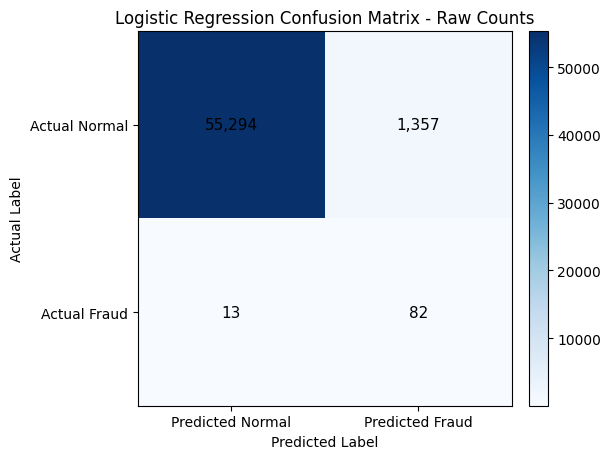


### Figure Interpretation

**What this figure shows:**  
The raw confusion matrix visualizes the count of Logistic Regression correct approvals, false alerts, missed frauds, and caught frauds.

**X-axis:**  
Predicted class: normal or fraud.

**Y-axis:**  
Actual class: normal or fraud.

**How to read it:**  
Large counts on the diagonal are correct predictions; off-diagonal counts are errors.

**Key finding:**  
At threshold 0.50, Logistic Regression produces 1,357 false positives and 13 false negatives.

**Business meaning:**  
The raw counts estimate operational review load and missed-fraud exposure for Logistic Regression.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/logistic_regression_confusion_matrix_normalized.png


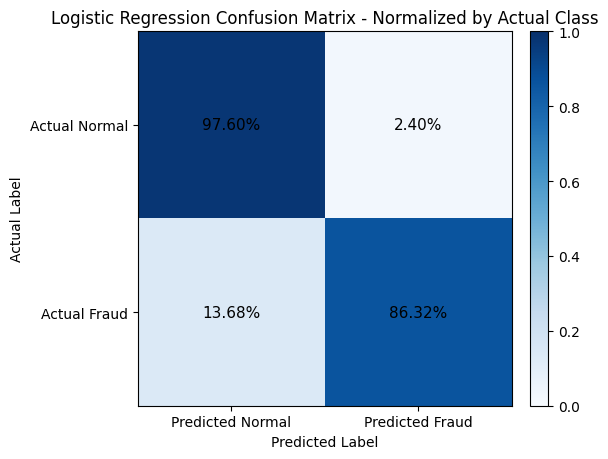


### Figure Interpretation

**What this figure shows:**  
The normalized confusion matrix shows Logistic Regression decisions as percentages within each actual class.

**X-axis:**  
Predicted class: normal or fraud.

**Y-axis:**  
Actual class: normal or fraud.

**How to read it:**  
Read each row as 100% of that actual class. The fraud row shows the percentage of fraud missed versus caught.

**Key finding:**  
The model catches 86.32% of fraud cases at threshold 0.50.

**Business meaning:**  
The normalized view shows that Logistic Regression is recall-oriented but can create more customer disruption than a tighter alert model.


In [61]:
logreg_default_pred = holdout_predictions["logistic_regression_prediction_0_5_recomputed"]
logreg_proba = holdout_predictions["logistic_regression_probability"]
logreg_results = evaluate_model("Logistic Regression", y_true, logreg_default_pred, logreg_proba)
logreg_report_df = classification_report_dataframe(y_true, logreg_default_pred)
logreg_cm = confusion_matrix(y_true, logreg_default_pred)
logreg_cm_df = confusion_matrix_dataframe(logreg_cm)
logreg_cm_normalized_df = normalized_confusion_matrix_dataframe(logreg_cm)
logreg_fraud_capture_pct = logreg_cm_normalized_df.loc["Actual Fraud (1)", "Predicted Fraud (1)"]
logreg_normal_false_alert_pct = logreg_cm_normalized_df.loc["Actual Normal (0)", "Predicted Fraud (1)"]

print("Logistic Regression Classification Report - Default Threshold 0.50")
display(logreg_report_df)
display_table_interpretation(
    purpose="This table reports Logistic Regression precision, recall, F1-score, and support at the default 0.50 threshold.",
    how_to_read="Class 0 is normal transactions and class 1 is fraud. Precision shows how clean the fraud alerts are; recall shows how many actual frauds are caught; support shows the number of examples in each class.",
    key_finding=f"For the fraud class, Logistic Regression has precision {logreg_results['precision']:.4f}, recall {logreg_results['recall']:.4f}, and F1-score {logreg_results['f1_score']:.4f} at threshold 0.50.",
    business_meaning=f"Logistic Regression catches a large share of fraud at 0.50, but its low precision means many more normal transactions are flagged than a precision-focused model would allow.",
    next_action="Compare this default-threshold result with Random Forest and with lower candidate thresholds in the threshold sensitivity analysis.",
)

print("Logistic Regression Raw Confusion Matrix")
display(logreg_cm_df)
display_table_interpretation(
    purpose="This table shows raw counts of correct and incorrect Logistic Regression decisions at threshold 0.50.",
    how_to_read="Rows are actual classes and columns are predicted classes. False positives are normal transactions predicted as fraud; false negatives are fraud transactions predicted as normal.",
    key_finding=f"The model caught {logreg_results['true_positives']:,} fraud cases and missed {logreg_results['false_negatives']:,} fraud cases, while creating {logreg_results['false_positives']:,} false alerts.",
    business_meaning=f"The {logreg_results['false_positives']:,} false positives show why Logistic Regression can increase analyst workload and customer friction even when recall is useful.",
    next_action="Use the normalized confusion matrix and threshold sweep to judge whether the operating threshold should move away from 0.50.",
)

print("Logistic Regression Normalized Confusion Matrix")
display(logreg_cm_normalized_df)
display_table_interpretation(
    purpose="This table converts Logistic Regression confusion-matrix counts into percentages within each actual class.",
    how_to_read="The normal row shows the percentage of normal transactions approved or wrongly flagged. The fraud row shows the percentage of fraud transactions missed or caught.",
    key_finding=f"Logistic Regression catches {logreg_fraud_capture_pct:.2%} of actual fraud and wrongly flags {logreg_normal_false_alert_pct:.2%} of normal transactions at threshold 0.50.",
    business_meaning="Class-normalized percentages make the recall-versus-false-alert trade-off clear despite the severe class imbalance.",
    next_action="Review the same percentages for Random Forest and then tune thresholds based on fraud capture and alert volume.",
)

logreg_cm_path = NOTEBOOK_FIGURES_DIR / "logistic_regression_confusion_matrix.png"
logreg_cm_normalized_path = NOTEBOOK_FIGURES_DIR / "logistic_regression_confusion_matrix_normalized.png"
plot_confusion_matrix_figure("Logistic Regression", logreg_cm, logreg_cm_path, normalized=False)
display_figure_interpretation(
    what="The raw confusion matrix visualizes the count of Logistic Regression correct approvals, false alerts, missed frauds, and caught frauds.",
    x_axis="Predicted class: normal or fraud.",
    y_axis="Actual class: normal or fraud.",
    how_to_read="Large counts on the diagonal are correct predictions; off-diagonal counts are errors.",
    key_finding=f"At threshold 0.50, Logistic Regression produces {logreg_results['false_positives']:,} false positives and {logreg_results['false_negatives']:,} false negatives.",
    business_meaning="The raw counts estimate operational review load and missed-fraud exposure for Logistic Regression.",
)
plot_confusion_matrix_figure("Logistic Regression", logreg_cm, logreg_cm_normalized_path, normalized=True)
display_figure_interpretation(
    what="The normalized confusion matrix shows Logistic Regression decisions as percentages within each actual class.",
    x_axis="Predicted class: normal or fraud.",
    y_axis="Actual class: normal or fraud.",
    how_to_read="Read each row as 100% of that actual class. The fraud row shows the percentage of fraud missed versus caught.",
    key_finding=f"The model catches {logreg_cm_normalized_df.loc['Actual Fraud (1)', 'Predicted Fraud (1)']:.2%} of fraud cases at threshold 0.50.",
    business_meaning="The normalized view shows that Logistic Regression is recall-oriented but can create more customer disruption than a tighter alert model.",
)


## Random Forest Default Threshold Evaluation

This section evaluates Random Forest at threshold `0.50` using predictions recomputed from `random_forest_probability >= 0.50`.


Random Forest Classification Report - Default Threshold 0.50


,class_or_average,precision,recall,f1-score,support
0,0,0.999559,0.999947,0.999753,56651.000000
1,1,0.958904,0.736842,0.833333,95.000000
2,accuracy,0.999507,0.999507,0.999507,0.999507
3,macro avg,0.979231,0.868395,0.916543,56746.000000
4,weighted avg,0.999491,0.999507,0.999474,56746.000000



### Table Interpretation

**Purpose:**  
This table reports Random Forest precision, recall, F1-score, and support at the default 0.50 threshold.

**How to read it:**  
Class 0 is normal transactions and class 1 is fraud. Precision shows how clean the fraud alerts are; recall shows how many actual frauds are caught; support shows class counts.

**Key finding:**  
For the fraud class, Random Forest has precision 0.9589, recall 0.7368, and F1-score 0.8333 at threshold 0.50.

**Business meaning:**  
Random Forest maintains high precision at 0.50, so it creates a cleaner alert queue while still catching a useful portion of fraud cases.

**Next action:**  
Compare it against Logistic Regression and then evaluate threshold alternatives.


Random Forest Raw Confusion Matrix


,Predicted Normal (0),Predicted Fraud (1)
Actual Normal (0),56648,3
Actual Fraud (1),25,70



### Table Interpretation

**Purpose:**  
This table shows raw counts of correct and incorrect Random Forest decisions at threshold 0.50.

**How to read it:**  
Rows are actual classes and columns are predicted classes. False positives are normal transactions predicted as fraud; false negatives are fraud transactions predicted as normal.

**Key finding:**  
The model caught 70 fraud cases and missed 25 fraud cases, while creating 3 false alerts.

**Business meaning:**  
Only 3 normal transactions are wrongly flagged at 0.50, which supports Random Forest as the cleaner operational candidate.

**Next action:**  
Use normalized percentages and threshold sensitivity to decide whether 0.50 is too strict.


Random Forest Normalized Confusion Matrix


,Predicted Normal (0),Predicted Fraud (1)
Actual Normal (0),0.999947,0.000053
Actual Fraud (1),0.263158,0.736842



### Table Interpretation

**Purpose:**  
This table converts Random Forest confusion-matrix counts into percentages within each actual class.

**How to read it:**  
The normal row shows the percentage of normal transactions approved or wrongly flagged. The fraud row shows the percentage of fraud transactions missed or caught.

**Key finding:**  
Random Forest catches 73.68% of actual fraud while wrongly flagging only 0.01% of normal transactions at threshold 0.50.

**Business meaning:**  
This percentage view shows why Random Forest gives stronger false-alert control than a high-recall baseline.

**Next action:**  
Move to model comparison and threshold sensitivity to select the strongest candidate for tuning.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/random_forest_confusion_matrix.png


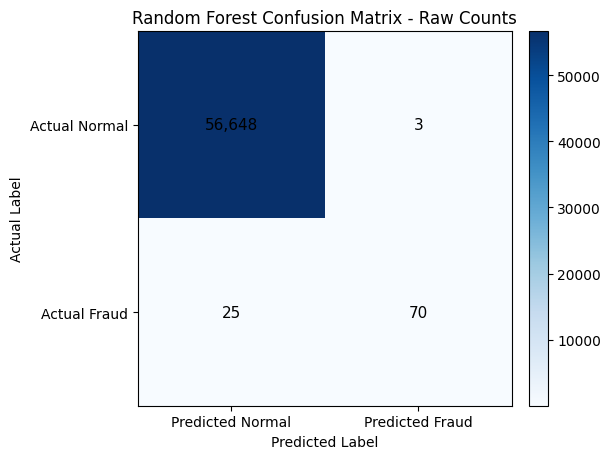


### Figure Interpretation

**What this figure shows:**  
The raw confusion matrix visualizes Random Forest correct approvals, false alerts, missed frauds, and caught frauds.

**X-axis:**  
Predicted class: normal or fraud.

**Y-axis:**  
Actual class: normal or fraud.

**How to read it:**  
Large counts on the diagonal are correct predictions; off-diagonal counts are errors.

**Key finding:**  
At threshold 0.50, Random Forest produces 3 false positives and 25 false negatives.

**Business meaning:**  
The raw count view shows Random Forest keeps false alerts low while preserving meaningful fraud capture.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/random_forest_confusion_matrix_normalized.png


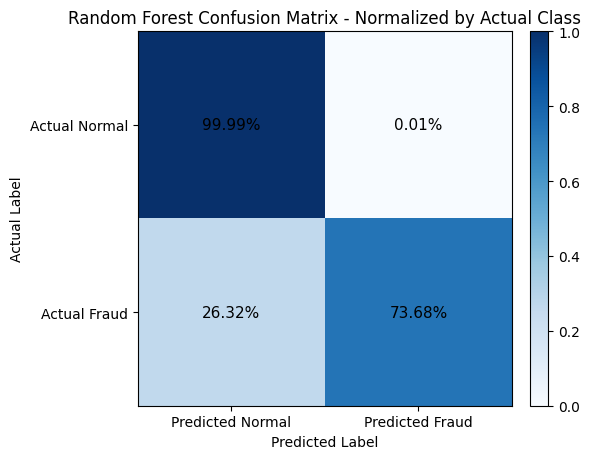


### Figure Interpretation

**What this figure shows:**  
The normalized confusion matrix shows Random Forest decisions as percentages within each actual class.

**X-axis:**  
Predicted class: normal or fraud.

**Y-axis:**  
Actual class: normal or fraud.

**How to read it:**  
Read each row as 100% of that actual class. The fraud row shows the percentage of fraud missed versus caught.

**Key finding:**  
The model catches 73.68% of fraud cases at threshold 0.50.

**Business meaning:**  
The normalized view supports carrying Random Forest into threshold tuning because it balances caught fraud and normal-transaction protection better at 0.50.


In [62]:
rf_default_pred = holdout_predictions["random_forest_prediction_0_5_recomputed"]
rf_proba = holdout_predictions["random_forest_probability"]
rf_results = evaluate_model("Random Forest", y_true, rf_default_pred, rf_proba)
rf_report_df = classification_report_dataframe(y_true, rf_default_pred)
rf_cm = confusion_matrix(y_true, rf_default_pred)
rf_cm_df = confusion_matrix_dataframe(rf_cm)
rf_cm_normalized_df = normalized_confusion_matrix_dataframe(rf_cm)
rf_fraud_capture_pct = rf_cm_normalized_df.loc["Actual Fraud (1)", "Predicted Fraud (1)"]
rf_normal_false_alert_pct = rf_cm_normalized_df.loc["Actual Normal (0)", "Predicted Fraud (1)"]

print("Random Forest Classification Report - Default Threshold 0.50")
display(rf_report_df)
display_table_interpretation(
    purpose="This table reports Random Forest precision, recall, F1-score, and support at the default 0.50 threshold.",
    how_to_read="Class 0 is normal transactions and class 1 is fraud. Precision shows how clean the fraud alerts are; recall shows how many actual frauds are caught; support shows class counts.",
    key_finding=f"For the fraud class, Random Forest has precision {rf_results['precision']:.4f}, recall {rf_results['recall']:.4f}, and F1-score {rf_results['f1_score']:.4f} at threshold 0.50.",
    business_meaning=f"Random Forest maintains high precision at 0.50, so it creates a cleaner alert queue while still catching a useful portion of fraud cases.",
    next_action="Compare it against Logistic Regression and then evaluate threshold alternatives.",
)

print("Random Forest Raw Confusion Matrix")
display(rf_cm_df)
display_table_interpretation(
    purpose="This table shows raw counts of correct and incorrect Random Forest decisions at threshold 0.50.",
    how_to_read="Rows are actual classes and columns are predicted classes. False positives are normal transactions predicted as fraud; false negatives are fraud transactions predicted as normal.",
    key_finding=f"The model caught {rf_results['true_positives']:,} fraud cases and missed {rf_results['false_negatives']:,} fraud cases, while creating {rf_results['false_positives']:,} false alerts.",
    business_meaning=f"Only {rf_results['false_positives']:,} normal transactions are wrongly flagged at 0.50, which supports Random Forest as the cleaner operational candidate.",
    next_action="Use normalized percentages and threshold sensitivity to decide whether 0.50 is too strict.",
)

print("Random Forest Normalized Confusion Matrix")
display(rf_cm_normalized_df)
display_table_interpretation(
    purpose="This table converts Random Forest confusion-matrix counts into percentages within each actual class.",
    how_to_read="The normal row shows the percentage of normal transactions approved or wrongly flagged. The fraud row shows the percentage of fraud transactions missed or caught.",
    key_finding=f"Random Forest catches {rf_fraud_capture_pct:.2%} of actual fraud while wrongly flagging only {rf_normal_false_alert_pct:.2%} of normal transactions at threshold 0.50.",
    business_meaning="This percentage view shows why Random Forest gives stronger false-alert control than a high-recall baseline.",
    next_action="Move to model comparison and threshold sensitivity to select the strongest candidate for tuning.",
)

rf_cm_path = NOTEBOOK_FIGURES_DIR / "random_forest_confusion_matrix.png"
rf_cm_normalized_path = NOTEBOOK_FIGURES_DIR / "random_forest_confusion_matrix_normalized.png"
plot_confusion_matrix_figure("Random Forest", rf_cm, rf_cm_path, normalized=False)
display_figure_interpretation(
    what="The raw confusion matrix visualizes Random Forest correct approvals, false alerts, missed frauds, and caught frauds.",
    x_axis="Predicted class: normal or fraud.",
    y_axis="Actual class: normal or fraud.",
    how_to_read="Large counts on the diagonal are correct predictions; off-diagonal counts are errors.",
    key_finding=f"At threshold 0.50, Random Forest produces {rf_results['false_positives']:,} false positives and {rf_results['false_negatives']:,} false negatives.",
    business_meaning="The raw count view shows Random Forest keeps false alerts low while preserving meaningful fraud capture.",
)
plot_confusion_matrix_figure("Random Forest", rf_cm, rf_cm_normalized_path, normalized=True)
display_figure_interpretation(
    what="The normalized confusion matrix shows Random Forest decisions as percentages within each actual class.",
    x_axis="Predicted class: normal or fraud.",
    y_axis="Actual class: normal or fraud.",
    how_to_read="Read each row as 100% of that actual class. The fraud row shows the percentage of fraud missed versus caught.",
    key_finding=f"The model catches {rf_cm_normalized_df.loc['Actual Fraud (1)', 'Predicted Fraud (1)']:.2%} of fraud cases at threshold 0.50.",
    business_meaning="The normalized view supports carrying Random Forest into threshold tuning because it balances caught fraud and normal-transaction protection better at 0.50.",
)


## Default Threshold Model Comparison

The table below compares both candidate models at the recomputed default threshold of `0.50`.


In [63]:
comparison_df = pd.DataFrame(
    [
        {
            "Model": logreg_results["model_name"],
            "Precision": logreg_results["precision"],
            "Recall": logreg_results["recall"],
            "F1-score": logreg_results["f1_score"],
            "ROC-AUC": logreg_results["roc_auc"],
            "PR-AUC": logreg_results["pr_auc"],
            "Predicted Fraud Count": logreg_results["predicted_fraud_count"],
            "Predicted Fraud Rate": logreg_results["predicted_fraud_rate"],
            "Predicted Fraud Rate (%)": logreg_results["predicted_fraud_rate_percent"],
            "True Negatives": logreg_results["true_negatives"],
            "False Positives": logreg_results["false_positives"],
            "False Negatives": logreg_results["false_negatives"],
            "True Positives": logreg_results["true_positives"],
        },
        {
            "Model": rf_results["model_name"],
            "Precision": rf_results["precision"],
            "Recall": rf_results["recall"],
            "F1-score": rf_results["f1_score"],
            "ROC-AUC": rf_results["roc_auc"],
            "PR-AUC": rf_results["pr_auc"],
            "Predicted Fraud Count": rf_results["predicted_fraud_count"],
            "Predicted Fraud Rate": rf_results["predicted_fraud_rate"],
            "Predicted Fraud Rate (%)": rf_results["predicted_fraud_rate_percent"],
            "True Negatives": rf_results["true_negatives"],
            "False Positives": rf_results["false_positives"],
            "False Negatives": rf_results["false_negatives"],
            "True Positives": rf_results["true_positives"],
        },
    ]
)
comparison_df["Business Interpretation"] = comparison_df.apply(build_business_interpretation, axis=1)
save_dataframe_with_notice(comparison_df, MODEL_COMPARISON_FILE, index=False)
save_dataframe_with_notice(comparison_df, NOTEBOOK_TABLES_DIR / "model_comparison.csv", index=False)

display(comparison_df)
best_default_model = comparison_df.sort_values(["F1-score", "PR-AUC"], ascending=False).iloc[0]
display_table_interpretation(
    purpose="This table compares Logistic Regression and Random Forest at the same recomputed default threshold of 0.50.",
    how_to_read="Rows are models. Metric columns compare fraud alert quality, fraud capture, ranking quality, alert volume, and confusion-matrix counts.",
    key_finding=f"At threshold 0.50, {best_default_model['Model']} has the highest F1-score ({best_default_model['F1-score']:.4f}) among the two candidates.",
    business_meaning="At threshold 0.50, Random Forest is more precision-focused and operationally cleaner, while Logistic Regression is useful for understanding high-recall behavior with heavier false-alert cost.",
    next_action="Use ranking curves, probability distributions, calibration, and threshold sensitivity before choosing the model for the next notebook.",
)


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/model_comparison.csv
Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/14_model_evaluation/model_comparison.csv


,Model,Precision,Recall,F1-score,ROC-AUC,PR-AUC,Predicted Fraud Count,Predicted Fraud Rate,Predicted Fraud Rate (%),True Negatives,False Positives,False Negatives,True Positives,Business Interpretation
0,Logistic Regression,0.056984,0.863158,0.106910,0.960592,0.641876,1439,0.025359,2.535862,55294,1357,13,82,"High fraud catch rate, but false alerts are hi..."
1,Random Forest,0.958904,0.736842,0.833333,0.924765,0.802161,73,0.001286,0.128643,56648,3,25,70,Low false-alert burden with strong precision; ...



### Table Interpretation

**Purpose:**  
This table compares Logistic Regression and Random Forest at the same recomputed default threshold of 0.50.

**How to read it:**  
Rows are models. Metric columns compare fraud alert quality, fraud capture, ranking quality, alert volume, and confusion-matrix counts.

**Key finding:**  
At threshold 0.50, Random Forest has the highest F1-score (0.8333) among the two candidates.

**Business meaning:**  
At threshold 0.50, Random Forest is more precision-focused and operationally cleaner, while Logistic Regression is useful for understanding high-recall behavior with heavier false-alert cost.

**Next action:**  
Use ranking curves, probability distributions, calibration, and threshold sensitivity before choosing the model for the next notebook.


<!-- FIXED: FIX 4: ROC-AUC LR vs RF Explanation -->


## ROC-AUC Analysis

ROC-AUC evaluates ranking/separation across many thresholds. It is useful, but it is not tied to one fixed threshold and should not be used alone for imbalanced fraud detection.

> **Why Logistic Regression shows higher ROC-AUC than Random Forest here:**
> Logistic Regression produces more spread-out probability scores (many values close to 0 or 1), which creates a smoother and more favorable ROC curve shape. Random Forest tends to cluster probabilities near the decision boundary, which can produce a lower ROC-AUC even when PR-AUC and F1-score are substantially better. PR-AUC is the authoritative ranking metric for this imbalanced problem — Random Forest's PR-AUC (0.80) far exceeds Logistic Regression's (0.64), which is why Random Forest is selected as the stronger candidate.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/roc_curve_comparison.png


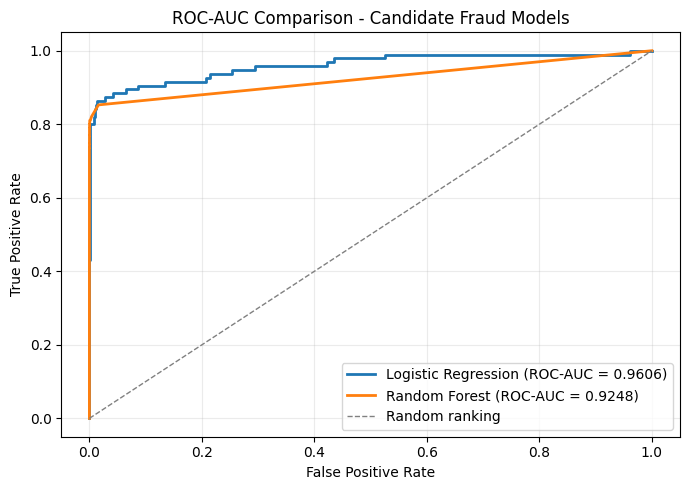


### Figure Interpretation

**What this figure shows:**  
This figure compares how well each model ranks fraud cases above normal cases across many thresholds.

**X-axis:**  
False Positive Rate, the share of normal transactions incorrectly flagged at different thresholds.

**Y-axis:**  
True Positive Rate, also called recall, the share of fraud cases caught at different thresholds.

**How to read it:**  
Curves closer to the top-left corner and farther above the diagonal random line indicate better separation. ROC-AUC is not tied to one fixed threshold. It measures ranking/separation ability across many possible thresholds.

**Key finding:**  
Logistic Regression has the stronger ROC-AUC in this holdout evaluation, but Random Forest is still preferred overall because PR-AUC, F1-score, top-risk ranking, and alert-volume behavior are more practical for this rare-fraud setting.

**Business meaning:**  
Because this fraud dataset is highly imbalanced, ROC-AUC should be interpreted together with PR-AUC, F1-score, recall, precision, and threshold analysis rather than used alone.


In [64]:
roc_output_path = NOTEBOOK_FIGURES_DIR / "roc_curve_comparison.png"
logreg_fpr, logreg_tpr, _ = roc_curve(y_true, logreg_proba)
rf_fpr, rf_tpr, _ = roc_curve(y_true, rf_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(logreg_fpr, logreg_tpr, label=f"Logistic Regression (ROC-AUC = {logreg_results['roc_auc']:.4f})", linewidth=2)
ax.plot(rf_fpr, rf_tpr, label=f"Random Forest (ROC-AUC = {rf_results['roc_auc']:.4f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random ranking")
ax.set_title("ROC-AUC Comparison - Candidate Fraud Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure_with_notice(fig, roc_output_path)
plt.show()
plt.close(fig)

roc_key = "Random Forest" if rf_results["roc_auc"] >= logreg_results["roc_auc"] else "Logistic Regression"
display_figure_interpretation(
    what="This figure compares how well each model ranks fraud cases above normal cases across many thresholds.",
    x_axis="False Positive Rate, the share of normal transactions incorrectly flagged at different thresholds.",
    y_axis="True Positive Rate, also called recall, the share of fraud cases caught at different thresholds.",
    how_to_read="Curves closer to the top-left corner and farther above the diagonal random line indicate better separation. ROC-AUC is not tied to one fixed threshold. It measures ranking/separation ability across many possible thresholds.",
    key_finding=f"{roc_key} has the stronger ROC-AUC in this holdout evaluation, but Random Forest is still preferred overall because PR-AUC, F1-score, top-risk ranking, and alert-volume behavior are more practical for this rare-fraud setting.",
    business_meaning="Because this fraud dataset is highly imbalanced, ROC-AUC should be interpreted together with PR-AUC, F1-score, recall, precision, and threshold analysis rather than used alone.",
)


## Precision-Recall Analysis

PR-AUC is especially important for imbalanced fraud detection because it focuses directly on the rare fraud class and the trade-off between catching fraud and creating false alerts.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/precision_recall_curve_comparison.png


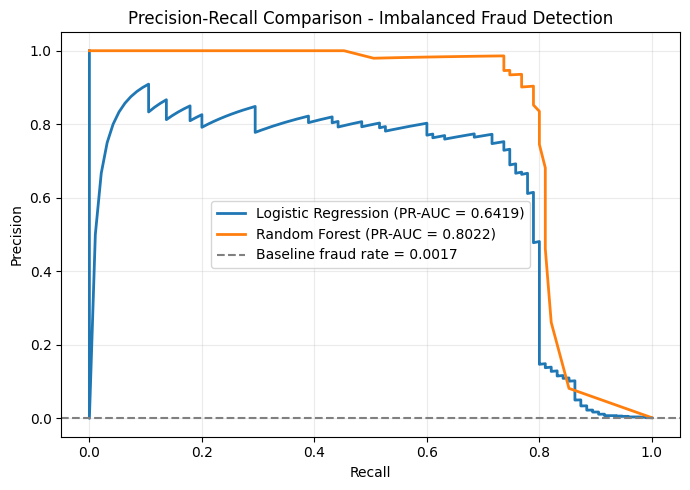


### Figure Interpretation

**What this figure shows:**  
This figure compares precision and recall trade-offs for the rare fraud class across thresholds.

**X-axis:**  
Recall, the percentage of actual fraud cases caught.

**Y-axis:**  
Precision, the percentage of flagged fraud cases that are truly fraud.

**How to read it:**  
A useful fraud model should stay far above the dashed baseline fraud-rate line. That baseline is the precision expected from random guessing.

**Key finding:**  
Random Forest has the stronger PR-AUC, and both curves should be judged relative to the baseline fraud rate of 0.1674%. PR-AUC is especially important here because fraud is the rare class. A model that stays above the fraud-rate baseline is giving better-than-random fraud ranking.

**Business meaning:**  
This supports Random Forest as the stronger practical candidate because it maintains better fraud-class ranking quality while keeping alert volume controlled.


In [65]:
pr_output_path = NOTEBOOK_FIGURES_DIR / "precision_recall_curve_comparison.png"
logreg_precision_curve, logreg_recall_curve, _ = precision_recall_curve(y_true, logreg_proba)
rf_precision_curve, rf_recall_curve, _ = precision_recall_curve(y_true, rf_proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(logreg_recall_curve, logreg_precision_curve, label=f"Logistic Regression (PR-AUC = {logreg_results['pr_auc']:.4f})", linewidth=2)
ax.plot(rf_recall_curve, rf_precision_curve, label=f"Random Forest (PR-AUC = {rf_results['pr_auc']:.4f})", linewidth=2)
ax.axhline(fraud_rate, linestyle="--", color="gray", linewidth=1.5, label=f"Baseline fraud rate = {fraud_rate:.4f}")
ax.set_title("Precision-Recall Comparison - Imbalanced Fraud Detection")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure_with_notice(fig, pr_output_path)
plt.show()
plt.close(fig)

pr_key = "Random Forest" if rf_results["pr_auc"] >= logreg_results["pr_auc"] else "Logistic Regression"
display_figure_interpretation(
    what="This figure compares precision and recall trade-offs for the rare fraud class across thresholds.",
    x_axis="Recall, the percentage of actual fraud cases caught.",
    y_axis="Precision, the percentage of flagged fraud cases that are truly fraud.",
    how_to_read="A useful fraud model should stay far above the dashed baseline fraud-rate line. That baseline is the precision expected from random guessing.",
    key_finding=f"{pr_key} has the stronger PR-AUC, and both curves should be judged relative to the baseline fraud rate of {fraud_rate:.4%}. PR-AUC is especially important here because fraud is the rare class. A model that stays above the fraud-rate baseline is giving better-than-random fraud ranking.",
    business_meaning="This supports Random Forest as the stronger practical candidate because it maintains better fraud-class ranking quality while keeping alert volume controlled.",
)


## Metric Comparison Bar Chart

This chart gives a compact view of default-threshold and ranking metrics for both candidate models.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/metric_bar_comparison.png


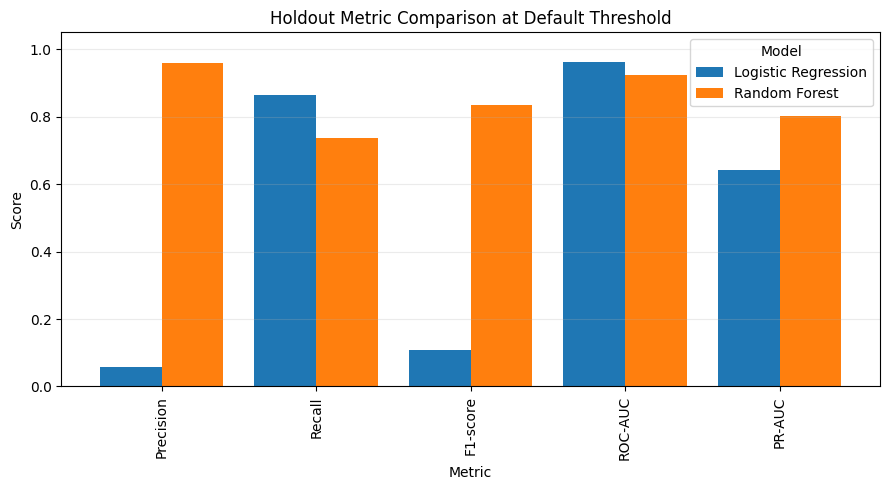


### Figure Interpretation

**What this figure shows:**  
This figure compares major holdout metrics for Logistic Regression and Random Forest.

**X-axis:**  
Evaluation metric.

**Y-axis:**  
Metric score from 0 to 1.

**How to read it:**  
Higher bars are better for each metric, but precision, recall, and F1 depend on the fixed 0.50 threshold while ROC-AUC and PR-AUC summarize ranking across thresholds.

**Key finding:**  
The strongest default-threshold F1 is from Random Forest, while PR-AUC should also guide the candidate model choice.

**Business meaning:**  
A practical fraud model needs both useful ranking quality and an operating threshold that controls false alerts; this comparison supports moving Random Forest forward for threshold tuning.


In [66]:
bar_output_path = NOTEBOOK_FIGURES_DIR / "metric_bar_comparison.png"
metrics_for_bar = comparison_df[["Model", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]].set_index("Model")
fig, ax = plt.subplots(figsize=(9, 5))
metrics_for_bar.T.plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Holdout Metric Comparison at Default Threshold")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(title="Model")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure_with_notice(fig, bar_output_path)
plt.show()
plt.close(fig)

display_figure_interpretation(
    what="This figure compares major holdout metrics for Logistic Regression and Random Forest.",
    x_axis="Evaluation metric.",
    y_axis="Metric score from 0 to 1.",
    how_to_read="Higher bars are better for each metric, but precision, recall, and F1 depend on the fixed 0.50 threshold while ROC-AUC and PR-AUC summarize ranking across thresholds.",
    key_finding=f"The strongest default-threshold F1 is from {best_default_model['Model']}, while PR-AUC should also guide the candidate model choice.",
    business_meaning="A practical fraud model needs both useful ranking quality and an operating threshold that controls false alerts; this comparison supports moving Random Forest forward for threshold tuning.",
)


## Probability Distribution Analysis

Probability distributions show whether a model assigns higher fraud probabilities to actual fraud cases than to normal transactions.


,model_name,actual_class_group,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
0,Logistic Regression,overall,56746,0.085646,0.133645,0.000000,0.001775,0.007594,0.012012,0.020737,0.041584,0.086219,0.198593,0.321062,0.797808,1.000000
1,Logistic Regression,actual_normal_0,56651,0.084335,0.129299,0.000000,0.001771,0.007589,0.012000,0.020714,0.041513,0.085830,0.196621,0.315688,0.752833,1.000000
2,Logistic Regression,actual_fraud_1,95,0.867057,0.297580,0.006309,0.036714,0.081551,0.240212,0.997265,0.999935,0.999998,1.000000,1.000000,1.000000,1.000000
3,Random Forest,overall,56746,0.001452,0.033148,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1.000000
4,Random Forest,actual_normal_0,56651,0.000292,0.006155,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,0.930000
5,Random Forest,actual_fraud_1,95,0.692842,0.395664,0.000000,0.000000,0.000000,0.000000,0.285000,0.930000,0.970000,0.990000,1.000000,1.000000,1.000000



### Table Interpretation

**Purpose:**  
This table summarizes predicted fraud probabilities overall and separately for actual normal and actual fraud transactions.

**How to read it:**  
Rows split each model by actual class. Quantile columns show the distribution of predicted fraud probabilities for each group.

**Key finding:**  
Random Forest median fraud probability is 0.9300 for actual fraud versus 0.0000 for actual normal transactions.

**Business meaning:**  
Random Forest assigns very low probabilities to most normal transactions and higher probabilities to many fraud transactions, which explains its stronger precision and controlled alert volume.

**Next action:**  
Inspect the distribution plots and then use threshold sensitivity to convert probabilities into decisions.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/probability_distribution_by_actual_class.png


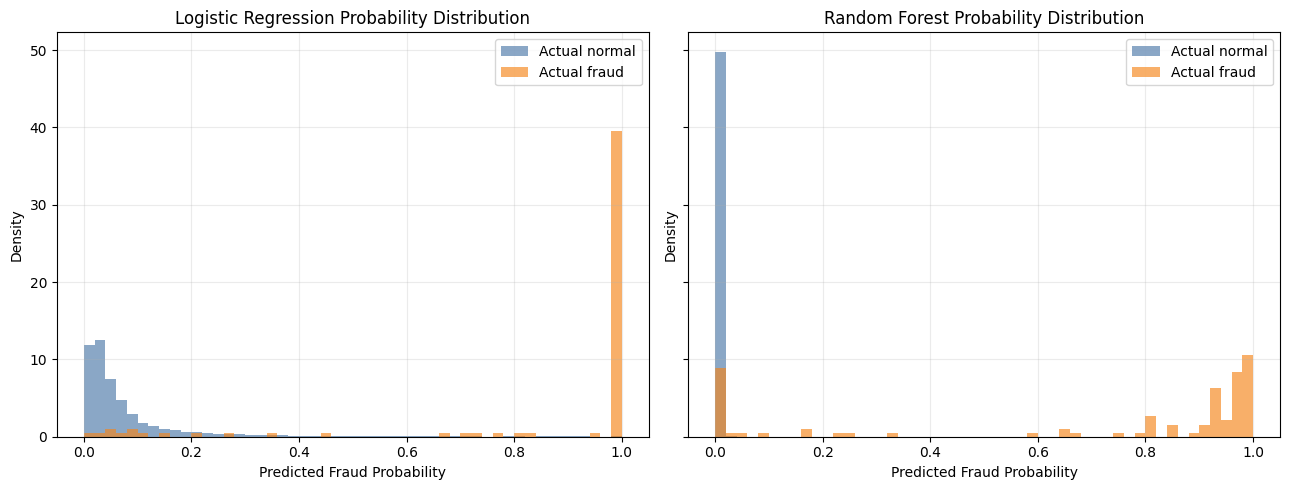


### Figure Interpretation

**What this figure shows:**  
This figure shows predicted fraud probability distributions for actual normal and actual fraud transactions for each model.

**X-axis:**  
Predicted fraud probability from 0 to 1.

**Y-axis:**  
Density, which shows where probability scores are concentrated within each actual class.

**How to read it:**  
A good model should place normal transactions near low probabilities and fraud transactions toward higher probabilities. Overlap means more classification mistakes at any single threshold.

**Key finding:**  
Random Forest keeps most normal transactions near very low fraud probabilities while assigning higher probabilities to many actual fraud transactions; Logistic Regression is more spread out and therefore creates more false alerts at comparable recall levels.

**Business meaning:**  
This supports using Random Forest for threshold tuning because its score distribution can produce cleaner fraud alerts and more controlled review volume.


In [67]:
logreg_probability_summary = summarize_probability_distribution(logreg_proba, y_true, "Logistic Regression")
rf_probability_summary = summarize_probability_distribution(rf_proba, y_true, "Random Forest")
probability_distribution_summary = pd.concat([logreg_probability_summary, rf_probability_summary], ignore_index=True)

display(probability_distribution_summary)
fraud_medians = probability_distribution_summary.loc[
    probability_distribution_summary["actual_class_group"] == "actual_fraud_1",
    ["model_name", "50%"],
].set_index("model_name")["50%"]
normal_medians = probability_distribution_summary.loc[
    probability_distribution_summary["actual_class_group"] == "actual_normal_0",
    ["model_name", "50%"],
].set_index("model_name")["50%"]
display_table_interpretation(
    purpose="This table summarizes predicted fraud probabilities overall and separately for actual normal and actual fraud transactions.",
    how_to_read="Rows split each model by actual class. Quantile columns show the distribution of predicted fraud probabilities for each group.",
    key_finding=f"Random Forest median fraud probability is {fraud_medians['Random Forest']:.4f} for actual fraud versus {normal_medians['Random Forest']:.4f} for actual normal transactions.",
    business_meaning="Random Forest assigns very low probabilities to most normal transactions and higher probabilities to many fraud transactions, which explains its stronger precision and controlled alert volume.",
    next_action="Inspect the distribution plots and then use threshold sensitivity to convert probabilities into decisions.",
)

probability_distribution_path = NOTEBOOK_FIGURES_DIR / "probability_distribution_by_actual_class.png"
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
model_specs = [
    ("Logistic Regression", logreg_proba, axes[0]),
    ("Random Forest", rf_proba, axes[1]),
]
for model_name, probabilities, ax in model_specs:
    normal_scores = pd.Series(probabilities)[y_true.values == 0]
    fraud_scores = pd.Series(probabilities)[y_true.values == 1]
    bins = np.linspace(0, 1, 51)
    ax.hist(normal_scores, bins=bins, alpha=0.65, density=True, label="Actual normal", color="#4C78A8")
    ax.hist(fraud_scores, bins=bins, alpha=0.65, density=True, label="Actual fraud", color="#F58518")
    ax.set_title(f"{model_name} Probability Distribution")
    ax.set_xlabel("Predicted Fraud Probability")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(alpha=0.25)
fig.tight_layout()
save_figure_with_notice(fig, probability_distribution_path)
plt.show()
plt.close(fig)

display_figure_interpretation(
    what="This figure shows predicted fraud probability distributions for actual normal and actual fraud transactions for each model.",
    x_axis="Predicted fraud probability from 0 to 1.",
    y_axis="Density, which shows where probability scores are concentrated within each actual class.",
    how_to_read="A good model should place normal transactions near low probabilities and fraud transactions toward higher probabilities. Overlap means more classification mistakes at any single threshold.",
    key_finding="Random Forest keeps most normal transactions near very low fraud probabilities while assigning higher probabilities to many actual fraud transactions; Logistic Regression is more spread out and therefore creates more false alerts at comparable recall levels.",
    business_meaning="This supports using Random Forest for threshold tuning because its score distribution can produce cleaner fraud alerts and more controlled review volume.",
)


## Calibration Analysis

Calibration checks whether predicted probabilities are reliable. For example, if a model predicts `0.80` fraud probability, calibration asks whether that risk level is meaningful in observed outcomes.


,model_name,brier_score,roc_auc,pr_auc
0,Logistic Regression,0.023967,0.960592,0.641876
1,Random Forest,0.000455,0.924765,0.802161



### Table Interpretation

**Purpose:**  
This table reports Brier score and ranking metrics for probability reliability checks.

**How to read it:**  
Lower Brier score means predicted probabilities are closer to actual outcomes. ROC-AUC and PR-AUC remain ranking metrics, not calibration metrics.

**Key finding:**  
Random Forest has the lower Brier score (0.000455) in this holdout check.

**Business meaning:**  
Calibration helps check whether predicted probabilities can be trusted as risk scores, but it should not override fraud-class performance evidence.

**Next action:**  
Use calibration evidence as a supporting check; candidate threshold rules should still be tuned with business costs and alert capacity.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/14_model_evaluation/calibration_curve_comparison.png


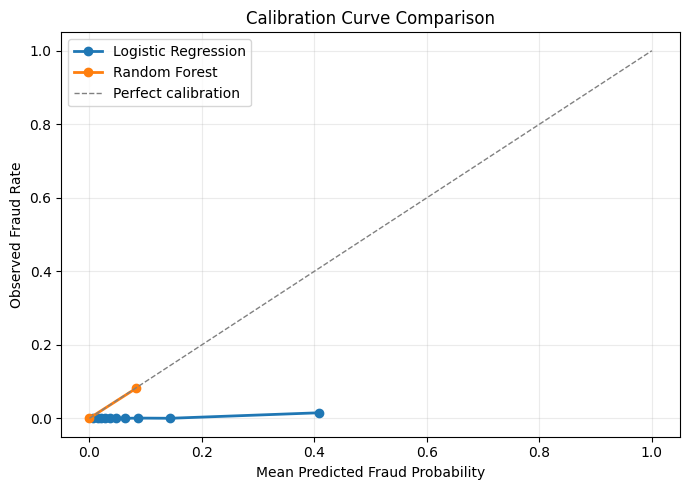


### Figure Interpretation

**What this figure shows:**  
This figure compares predicted fraud probabilities with observed fraud rates in probability bins.

**X-axis:**  
Mean predicted fraud probability within each bin.

**Y-axis:**  
Observed fraud rate within each bin.

**How to read it:**  
A well-calibrated model follows the dashed diagonal line. Points above or below the line indicate under- or over-estimated risk.

**Key finding:**  
Calibration quality should be considered before treating probability values as direct business risk levels.

**Business meaning:**  
Calibration helps check whether predicted probabilities can be trusted as risk scores. Because fraud is extremely rare, calibration metrics should not be interpreted alone; they should be reviewed with PR-AUC, threshold behavior, and business cost.



### Calibration Caution

Calibration is useful because this project uses fraud probabilities for risk-based decisions. However, because fraud cases are extremely rare, calibration metrics can look strong even when minority-class performance still needs careful review. Therefore, calibration should be interpreted together with PR-AUC, threshold behavior, confusion matrix results, alert volume, and business cost.



In [68]:
calibration_rows = []
calibration_specs = [
    ("Logistic Regression", logreg_proba),
    ("Random Forest", rf_proba),
]
for model_name, probabilities in calibration_specs:
    calibration_rows.append(
        {
            "model_name": model_name,
            "brier_score": brier_score_loss(y_true, probabilities),
            "roc_auc": roc_auc_score(y_true, probabilities),
            "pr_auc": average_precision_score(y_true, probabilities),
        }
    )
calibration_summary = pd.DataFrame(calibration_rows)
display(calibration_summary)
best_brier = calibration_summary.sort_values("brier_score", ascending=True).iloc[0]
display_table_interpretation(
    purpose="This table reports Brier score and ranking metrics for probability reliability checks.",
    how_to_read="Lower Brier score means predicted probabilities are closer to actual outcomes. ROC-AUC and PR-AUC remain ranking metrics, not calibration metrics.",
    key_finding=f"{best_brier['model_name']} has the lower Brier score ({best_brier['brier_score']:.6f}) in this holdout check.",
    business_meaning="Calibration helps check whether predicted probabilities can be trusted as risk scores, but it should not override fraud-class performance evidence.",
    next_action="Use calibration evidence as a supporting check; candidate threshold rules should still be tuned with business costs and alert capacity.",
)

calibration_curve_path = NOTEBOOK_FIGURES_DIR / "calibration_curve_comparison.png"
fig, ax = plt.subplots(figsize=(7, 5))
for model_name, probabilities in calibration_specs:
    prob_true, prob_pred = calibration_curve(y_true, probabilities, n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", linewidth=2, label=model_name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Perfect calibration")
ax.set_title("Calibration Curve Comparison")
ax.set_xlabel("Mean Predicted Fraud Probability")
ax.set_ylabel("Observed Fraud Rate")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
save_figure_with_notice(fig, calibration_curve_path)
plt.show()
plt.close(fig)

display_figure_interpretation(
    what="This figure compares predicted fraud probabilities with observed fraud rates in probability bins.",
    x_axis="Mean predicted fraud probability within each bin.",
    y_axis="Observed fraud rate within each bin.",
    how_to_read="A well-calibrated model follows the dashed diagonal line. Points above or below the line indicate under- or over-estimated risk.",
    key_finding="Calibration quality should be considered before treating probability values as direct business risk levels.",
    business_meaning="Calibration helps check whether predicted probabilities can be trusted as risk scores. Because fraud is extremely rare, calibration metrics should not be interpreted alone; they should be reviewed with PR-AUC, threshold behavior, and business cost.",
)

display(Markdown(f"""
### Calibration Caution

Calibration is useful because this project uses fraud probabilities for risk-based decisions. However, because fraud cases are extremely rare, calibration metrics can look strong even when minority-class performance still needs careful review. Therefore, calibration should be interpreted together with PR-AUC, threshold behavior, confusion matrix results, alert volume, and business cost.

"""))


## Top-Risk Ranking Analysis

Top-risk ranking checks whether the highest model scores contain a meaningful concentration of actual fraud cases.


In [69]:
logreg_top_30, logreg_top_k_hits = inspect_top_risk_cases(
    holdout_predictions,
    model_name="Logistic Regression",
    probability_column="logistic_regression_probability",
    top_n=30,
)
rf_top_30, rf_top_k_hits = inspect_top_risk_cases(
    holdout_predictions,
    model_name="Random Forest",
    probability_column="random_forest_probability",
    top_n=30,
)

top_risk_transactions = pd.concat([logreg_top_30, rf_top_30], ignore_index=True)
top_k_ranking_summary = pd.concat([logreg_top_k_hits, rf_top_k_hits], ignore_index=True)

print("Top 30 Highest-Risk Transactions")
display(top_risk_transactions)
display_table_interpretation(
    purpose="This table lists the highest-scored holdout transactions for each model.",
    how_to_read="Rows are ranked by predicted fraud probability within each model. `y_true=1` means the ranked transaction was actual fraud.",
    key_finding="The top-ranked rows show that the model scores can be used to prioritize suspicious transactions before choosing a final business operating rule.",
    business_meaning="Random Forest places more actual fraud cases near the top-ranked suspicious transactions, which is valuable when fraud analysts can only review a limited number of alerts.",
    next_action="Use the top-k summary to compare concentration of fraud at realistic review volumes.",
)

print("Top-K Fraud Capture Summary")
display(top_k_ranking_summary)
best_top100 = top_k_ranking_summary.loc[top_k_ranking_summary["top_k"] == 100].sort_values("actual_fraud_in_top_k", ascending=False).iloc[0]
display_table_interpretation(
    purpose="This table summarizes how many actual fraud cases appear in the top-k highest-risk transactions for each model.",
    how_to_read="Each row shows a model and review cutoff. `fraud_capture_rate` is the share of all holdout fraud cases found within that top-k set.",
    key_finding=f"At top 100 transactions, {best_top100['model_name']} captures {int(best_top100['actual_fraud_in_top_k'])} fraud cases.",
    business_meaning="Top-k ranking quality matters when fraud teams can only review a limited number of alerts; stronger top-k concentration supports Random Forest for analyst queues.",
    next_action="Carry the stronger ranking model into threshold tuning and alert-capacity analysis.",
)


Top 30 Highest-Risk Transactions


,rank,model_name,transaction_id,y_true,logistic_regression_probability,random_forest_probability
0,1,Logistic Regression,273745,0,1.000000,NaN
1,2,Logistic Regression,153640,1,1.000000,NaN
2,3,Logistic Regression,153242,1,1.000000,NaN
3,4,Logistic Regression,43498,1,1.000000,NaN
4,5,Logistic Regression,150420,1,1.000000,NaN
5,6,Logistic Regression,150337,1,1.000000,NaN
6,7,Logistic Regression,42979,1,1.000000,NaN
7,8,Logistic Regression,15683,1,1.000000,NaN
8,9,Logistic Regression,15423,1,1.000000,NaN
9,10,Logistic Regression,42755,1,1.000000,NaN



### Table Interpretation

**Purpose:**  
This table lists the highest-scored holdout transactions for each model.

**How to read it:**  
Rows are ranked by predicted fraud probability within each model. `y_true=1` means the ranked transaction was actual fraud.

**Key finding:**  
The top-ranked rows show that the model scores can be used to prioritize suspicious transactions before choosing a final business operating rule.

**Business meaning:**  
Random Forest places more actual fraud cases near the top-ranked suspicious transactions, which is valuable when fraud analysts can only review a limited number of alerts.

**Next action:**  
Use the top-k summary to compare concentration of fraud at realistic review volumes.


Top-K Fraud Capture Summary


,model_name,top_k,actual_fraud_in_top_k,fraud_capture_rate,precision_at_top_k
0,Logistic Regression,10,9,0.094737,0.900000
1,Logistic Regression,25,20,0.210526,0.800000
2,Logistic Regression,50,41,0.431579,0.820000
3,Logistic Regression,100,71,0.747368,0.710000
4,Logistic Regression,250,76,0.800000,0.304000
5,Logistic Regression,500,76,0.800000,0.152000
6,Random Forest,10,10,0.105263,1.000000
7,Random Forest,25,25,0.263158,1.000000
8,Random Forest,50,49,0.515789,0.980000
9,Random Forest,100,76,0.800000,0.760000



### Table Interpretation

**Purpose:**  
This table summarizes how many actual fraud cases appear in the top-k highest-risk transactions for each model.

**How to read it:**  
Each row shows a model and review cutoff. `fraud_capture_rate` is the share of all holdout fraud cases found within that top-k set.

**Key finding:**  
At top 100 transactions, Random Forest captures 76 fraud cases.

**Business meaning:**  
Top-k ranking quality matters when fraud teams can only review a limited number of alerts; stronger top-k concentration supports Random Forest for analyst queues.

**Next action:**  
Carry the stronger ranking model into threshold tuning and alert-capacity analysis.


## Threshold Sensitivity Analysis

The default `0.50` threshold is only a starting point. This section evaluates how precision, recall, F1-score, and alert volume change across thresholds. The threshold `0.150` is treated as a candidate threshold if selected by F1-score, not as the final production threshold.


In [70]:
thresholds = [
    0.01, 0.02, 0.03, 0.04, 0.05,
    0.075, 0.10, 0.15, 0.20, 0.25,
    0.30, 0.35, 0.40, 0.45, 0.50,
    0.60, 0.70, 0.80, 0.90,
]

logreg_threshold_sweep = run_threshold_sweep("Logistic Regression", y_true, logreg_proba, thresholds)
rf_threshold_sweep = run_threshold_sweep("Random Forest", y_true, rf_proba, thresholds)
threshold_sensitivity_sweep = pd.concat([logreg_threshold_sweep, rf_threshold_sweep], ignore_index=True)

save_dataframe_with_notice(threshold_sensitivity_sweep, THRESHOLD_SWEEP_FILE, index=False)
save_dataframe_with_notice(threshold_sensitivity_sweep, NOTEBOOK_TABLES_DIR / "threshold_sensitivity_sweep.csv", index=False)

display(threshold_sensitivity_sweep)
rf_050 = threshold_sensitivity_sweep.query("model_name == 'Random Forest' and threshold == 0.50").iloc[0]
assert np.isclose(rf_050["precision"], rf_results["precision"])
assert np.isclose(rf_050["recall"], rf_results["recall"])
assert np.isclose(rf_050["f1"], rf_results["f1_score"])
logreg_050 = threshold_sensitivity_sweep.query("model_name == 'Logistic Regression' and threshold == 0.50").iloc[0]
assert np.isclose(logreg_050["precision"], logreg_results["precision"])
assert np.isclose(logreg_050["recall"], logreg_results["recall"])
assert np.isclose(logreg_050["f1"], logreg_results["f1_score"])

display_table_interpretation(
    purpose="This table shows model performance and alert volume at multiple probability thresholds.",
    how_to_read="Each row is one model-threshold combination. Lower thresholds usually catch more fraud and create more alerts; higher thresholds usually reduce alerts and may miss more fraud.",
    key_finding=f"The threshold 0.50 rows now match the recomputed default-threshold evaluation. Random Forest reaches its best F1-score at threshold {rf_candidate['threshold']:.3f}, with precision {rf_candidate['precision']:.4f}, recall {rf_candidate['recall']:.4f}, and alert rate {rf_candidate['predicted_fraud_rate']:.2%}.",
    business_meaning="Threshold 0.150 gives Random Forest the best F1-score in this notebook, but it should be treated as a candidate operating threshold because fraud operations still need business-cost and alert-capacity validation.",
    next_action="Use this sensitivity table to choose candidate thresholds for formal business-cost analysis in `15_threshold_tuning.ipynb`.",
)

logreg_best_thresholds = extract_best_thresholds(threshold_sensitivity_sweep, "Logistic Regression")
rf_best_thresholds = extract_best_thresholds(threshold_sensitivity_sweep, "Random Forest")
best_threshold_summary = pd.concat([logreg_best_thresholds, rf_best_thresholds], ignore_index=True)
display(best_threshold_summary)
rf_candidate = best_threshold_summary.query("model_name == 'Random Forest' and selection_rule == 'best_f1_candidate_threshold'").iloc[0]
display_table_interpretation(
    purpose="This table summarizes candidate thresholds selected by F1-score and recall-constrained rules.",
    how_to_read="Rows are threshold selection rules. The best-F1 row is a candidate operating point; recall-constrained rows show thresholds that preserve minimum fraud capture when available.",
    key_finding=f"Random Forest's best-F1 candidate threshold in this sweep is {rf_candidate['threshold']:.3f}, with F1-score {rf_candidate['f1']:.4f} and alert rate {rf_candidate['predicted_fraud_rate']:.2%}.",
    business_meaning="A candidate threshold gives a promising review cutoff, but it is not a final production decision rule.",
    next_action="Validate candidate thresholds with business-cost analysis, review capacity, and `BLOCK` / `REVIEW` / `APPROVE` rules in the next notebook.",
)


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/threshold_sensitivity_sweep.csv
Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/14_model_evaluation/threshold_sensitivity_sweep.csv


,model_name,threshold,precision,recall,f1,predicted_fraud_count,predicted_fraud_rate,predicted_fraud_rate_percent,true_positives,false_positives,false_negatives,true_negatives
0,Logistic Regression,0.010000,0.001791,0.989474,0.003575,52488,0.924964,92.496387,94,52394,1,4257
1,Logistic Regression,0.020000,0.002170,0.989474,0.004330,43322,0.763437,76.343707,94,43228,1,13423
2,Logistic Regression,0.030000,0.002684,0.989474,0.005353,35024,0.617206,61.720650,94,34930,1,21721
3,Logistic Regression,0.040000,0.003188,0.978947,0.006355,29172,0.514080,51.408029,93,29079,2,27572
4,Logistic Regression,0.050000,0.003764,0.968421,0.007499,24443,0.430744,43.074402,92,24351,3,32300
5,Logistic Regression,0.075000,0.005490,0.947368,0.010918,16392,0.288866,28.886618,90,16302,5,40349
6,Logistic Regression,0.100000,0.007300,0.926316,0.014487,12054,0.212420,21.242026,88,11966,7,44685
7,Logistic Regression,0.150000,0.011041,0.915789,0.021818,7880,0.138864,13.886441,87,7793,8,48858
8,Logistic Regression,0.200000,0.015305,0.905263,0.030102,5619,0.099020,9.902020,86,5533,9,51118
9,Logistic Regression,0.250000,0.020137,0.894737,0.039388,4221,0.074384,7.438410,85,4136,10,52515



### Table Interpretation

**Purpose:**  
This table shows model performance and alert volume at multiple probability thresholds.

**How to read it:**  
Each row is one model-threshold combination. Lower thresholds usually catch more fraud and create more alerts; higher thresholds usually reduce alerts and may miss more fraud.

**Key finding:**  
The threshold 0.50 rows now match the recomputed default-threshold evaluation. Random Forest reaches its best F1-score at threshold 0.150, with precision 0.8929, recall 0.7895, and alert rate 0.15%.

**Business meaning:**  
Threshold 0.150 gives Random Forest the best F1-score in this notebook, but it should be treated as a candidate operating threshold because fraud operations still need business-cost and alert-capacity validation.

**Next action:**  
Use this sensitivity table to choose candidate thresholds for formal business-cost analysis in `15_threshold_tuning.ipynb`.


,model_name,selection_rule,threshold,precision,recall,f1,predicted_fraud_count,predicted_fraud_rate,predicted_fraud_rate_percent
0,Logistic Regression,best_f1_candidate_threshold,0.900000,0.264808,0.800000,0.397906,287,0.005058,0.505763
1,Logistic Regression,highest_precision_with_recall_at_least_0.70,0.900000,0.264808,0.800000,0.397906,287,0.005058,0.505763
2,Logistic Regression,highest_precision_with_recall_at_least_0.80,0.900000,0.264808,0.800000,0.397906,287,0.005058,0.505763
3,Random Forest,best_f1_candidate_threshold,0.150000,0.892857,0.789474,0.837989,84,0.001480,0.148028
4,Random Forest,highest_precision_with_recall_at_least_0.70,0.600000,0.985714,0.726316,0.836364,70,0.001234,0.123357
5,Random Forest,highest_precision_with_recall_at_least_0.80,0.075000,0.835165,0.800000,0.817204,91,0.001604,0.160364



### Table Interpretation

**Purpose:**  
This table summarizes candidate thresholds selected by F1-score and recall-constrained rules.

**How to read it:**  
Rows are threshold selection rules. The best-F1 row is a candidate operating point; recall-constrained rows show thresholds that preserve minimum fraud capture when available.

**Key finding:**  
Random Forest's best-F1 candidate threshold in this sweep is 0.150, with F1-score 0.8380 and alert rate 0.15%.

**Business meaning:**  
A candidate threshold gives a promising review cutoff, but it is not a final production decision rule.

**Next action:**  
Validate candidate thresholds with business-cost analysis, review capacity, and `BLOCK` / `REVIEW` / `APPROVE` rules in the next notebook.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/precision_vs_threshold.png


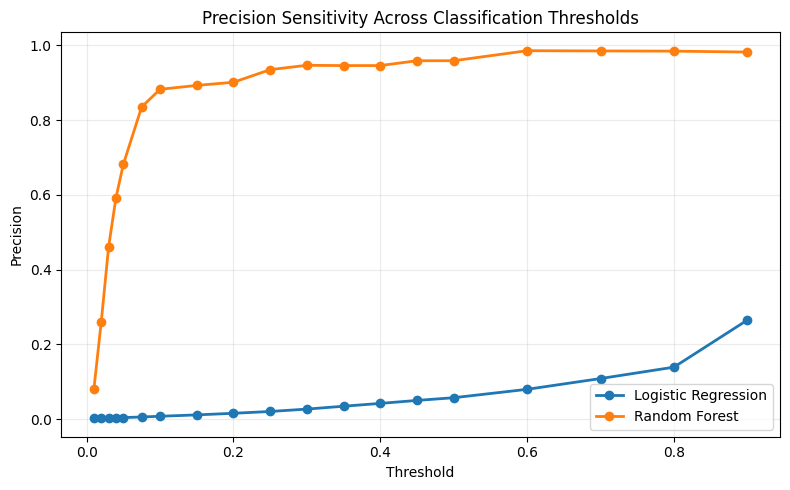


### Figure Interpretation

**What this figure shows:**  
This figure shows how fraud alert precision changes as the classification threshold changes.

**X-axis:**  
Fraud probability threshold.

**Y-axis:**  
Precision, or the share of flagged transactions that are actual fraud.

**How to read it:**  
Higher precision means fewer false alerts. Precision often increases as the threshold becomes stricter, but recall may decrease.

**Key finding:**  
Random Forest keeps stronger precision across useful operating regions, while Logistic Regression requires accepting many more false positives to capture fraud.

**Business meaning:**  
This supports Random Forest when the goal is cleaner alerts and lower customer friction.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/recall_vs_threshold.png


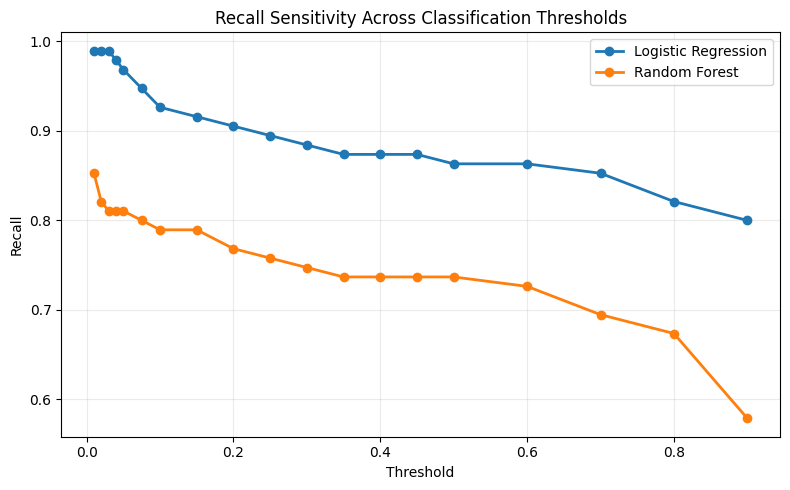


### Figure Interpretation

**What this figure shows:**  
This figure shows how fraud capture changes as the classification threshold changes.

**X-axis:**  
Fraud probability threshold.

**Y-axis:**  
Recall, or the share of actual fraud cases caught.

**How to read it:**  
Higher recall means fewer missed fraud cases. Recall usually decreases as the threshold becomes stricter.

**Key finding:**  
Logistic Regression can produce high recall at lower thresholds, but Random Forest offers a better recall-to-alert-quality trade-off for the next tuning stage.

**Business meaning:**  
Recall controls fraud loss exposure, but it must be balanced against the false-alert burden shown in the precision and alert-volume plots.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/f1_vs_threshold.png


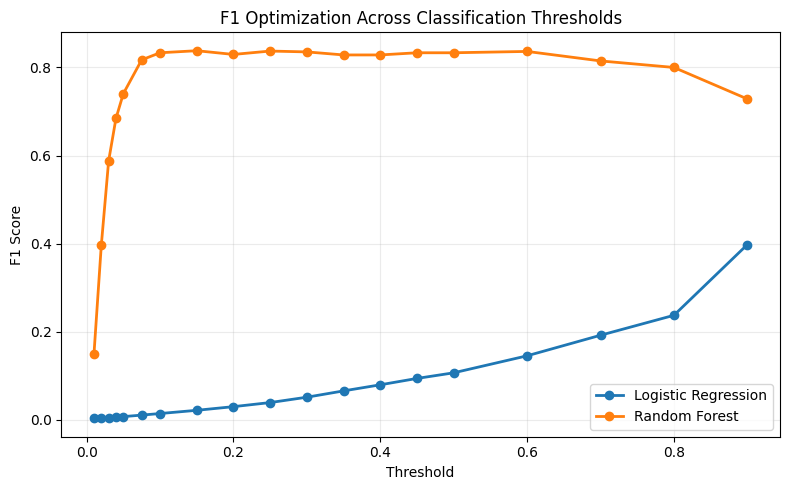


### Figure Interpretation

**What this figure shows:**  
This figure shows the balance between precision and recall at each tested threshold.

**X-axis:**  
Fraud probability threshold.

**Y-axis:**  
F1-score, the harmonic mean of precision and recall.

**How to read it:**  
The peak indicates the tested threshold with the best precision-recall balance by F1-score.

**Key finding:**  
Random Forest's best-F1 candidate threshold is 0.150, but this is a candidate threshold rather than the final production threshold.

**Business meaning:**  
F1 identifies Random Forest threshold 0.150 as the best tested balance, but business costs may still prefer a different candidate threshold.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/figures/alert_volume_vs_threshold.png


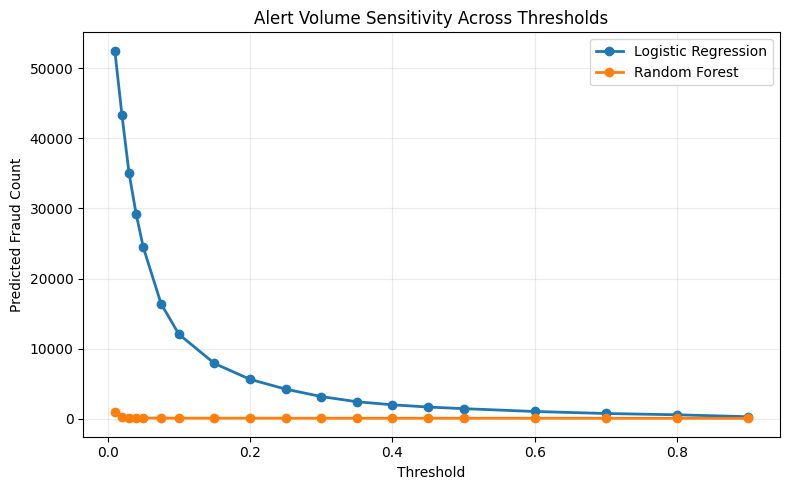


### Figure Interpretation

**What this figure shows:**  
This figure shows how many transactions would be flagged as fraud or review at each threshold.

**X-axis:**  
Fraud probability threshold.

**Y-axis:**  
Predicted fraud count, also interpreted as alert volume.

**How to read it:**  
Lower thresholds usually increase alert volume; higher thresholds usually decrease alert volume.

**Key finding:**  
At the Random Forest candidate threshold 0.150, the model flags 84 transactions, or 0.15% of the holdout set.

**Business meaning:**  
Fraud detection needs to catch fraud while keeping the alert queue manageable for analysts and customer operations; this supports validating Random Forest alert volume in the next notebook.


In [71]:
precision_path = REPORTS_FIGURES_DIR / "precision_vs_threshold.png"
recall_path = REPORTS_FIGURES_DIR / "recall_vs_threshold.png"
f1_path = REPORTS_FIGURES_DIR / "f1_vs_threshold.png"
alert_volume_path = REPORTS_FIGURES_DIR / "alert_volume_vs_threshold.png"

plot_threshold_curve(
    threshold_sensitivity_sweep,
    metric_name="precision",
    output_path=precision_path,
    title="Precision Sensitivity Across Classification Thresholds",
    y_label="Precision",
)
display_figure_interpretation(
    what="This figure shows how fraud alert precision changes as the classification threshold changes.",
    x_axis="Fraud probability threshold.",
    y_axis="Precision, or the share of flagged transactions that are actual fraud.",
    how_to_read="Higher precision means fewer false alerts. Precision often increases as the threshold becomes stricter, but recall may decrease.",
    key_finding=f"Random Forest keeps stronger precision across useful operating regions, while Logistic Regression requires accepting many more false positives to capture fraud.",
    business_meaning="This supports Random Forest when the goal is cleaner alerts and lower customer friction.",
)

plot_threshold_curve(
    threshold_sensitivity_sweep,
    metric_name="recall",
    output_path=recall_path,
    title="Recall Sensitivity Across Classification Thresholds",
    y_label="Recall",
)
display_figure_interpretation(
    what="This figure shows how fraud capture changes as the classification threshold changes.",
    x_axis="Fraud probability threshold.",
    y_axis="Recall, or the share of actual fraud cases caught.",
    how_to_read="Higher recall means fewer missed fraud cases. Recall usually decreases as the threshold becomes stricter.",
    key_finding="Logistic Regression can produce high recall at lower thresholds, but Random Forest offers a better recall-to-alert-quality trade-off for the next tuning stage.",
    business_meaning="Recall controls fraud loss exposure, but it must be balanced against the false-alert burden shown in the precision and alert-volume plots.",
)

plot_threshold_curve(
    threshold_sensitivity_sweep,
    metric_name="f1",
    output_path=f1_path,
    title="F1 Optimization Across Classification Thresholds",
    y_label="F1 Score",
)
display_figure_interpretation(
    what="This figure shows the balance between precision and recall at each tested threshold.",
    x_axis="Fraud probability threshold.",
    y_axis="F1-score, the harmonic mean of precision and recall.",
    how_to_read="The peak indicates the tested threshold with the best precision-recall balance by F1-score.",
    key_finding=f"Random Forest's best-F1 candidate threshold is {rf_candidate['threshold']:.3f}, but this is a candidate threshold rather than the final production threshold.",
    business_meaning="F1 identifies Random Forest threshold 0.150 as the best tested balance, but business costs may still prefer a different candidate threshold.",
)

plot_threshold_curve(
    threshold_sensitivity_sweep,
    metric_name="predicted_fraud_count",
    output_path=alert_volume_path,
    title="Alert Volume Sensitivity Across Thresholds",
    y_label="Predicted Fraud Count",
)
display_figure_interpretation(
    what="This figure shows how many transactions would be flagged as fraud or review at each threshold.",
    x_axis="Fraud probability threshold.",
    y_axis="Predicted fraud count, also interpreted as alert volume.",
    how_to_read="Lower thresholds usually increase alert volume; higher thresholds usually decrease alert volume.",
    key_finding=f"At the Random Forest candidate threshold {rf_candidate['threshold']:.3f}, the model flags {int(rf_candidate['predicted_fraud_count'])} transactions, or {rf_candidate['predicted_fraud_rate']:.2%} of the holdout set.",
    business_meaning="Fraud detection needs to catch fraud while keeping the alert queue manageable for analysts and customer operations; this supports validating Random Forest alert volume in the next notebook.",
)


## Candidate Model Selection

Random Forest is selected as the strongest candidate model only if the computed evidence supports it across PR-AUC, F1-score, top-risk ranking, and controlled alert volume. The selected candidate threshold is not a final production threshold.


In [72]:
holdout_probability_metrics = pd.DataFrame(
    [
        {"model_name": "Logistic Regression", "roc_auc": logreg_results["roc_auc"], "pr_auc": logreg_results["pr_auc"]},
        {"model_name": "Random Forest", "roc_auc": rf_results["roc_auc"], "pr_auc": rf_results["pr_auc"]},
    ]
)
display(holdout_probability_metrics)
display_table_interpretation(
    purpose="This table summarizes threshold-independent ranking metrics for both candidate models.",
    how_to_read="ROC-AUC measures general ranking/separation across thresholds. PR-AUC focuses on ranking quality for the rare fraud class.",
    key_finding=f"Random Forest PR-AUC is {rf_results['pr_auc']:.4f}, compared with Logistic Regression PR-AUC of {logreg_results['pr_auc']:.4f}.",
    business_meaning="PR-AUC is especially important because fraud is rare and false alerts are costly; Random Forest's stronger PR-AUC supports it as the more practical candidate.",
    next_action="Combine PR-AUC with threshold-sweep F1, top-risk ranking, and alert volume to select the candidate model.",
)

best_f1_by_model = (
    threshold_sensitivity_sweep.sort_values(["model_name", "f1", "precision", "recall"], ascending=[True, False, False, False])
    .groupby("model_name", as_index=False)
    .first()
)
best_f1_lookup = best_f1_by_model.set_index("model_name")
probability_lookup = holdout_probability_metrics.set_index("model_name")
top100_lookup = top_k_ranking_summary.loc[top_k_ranking_summary["top_k"] == 100].set_index("model_name")

rf_best = best_f1_lookup.loc["Random Forest"]
lr_best = best_f1_lookup.loc["Logistic Regression"]
rf_prob = probability_lookup.loc["Random Forest"]
lr_prob = probability_lookup.loc["Logistic Regression"]
rf_top100 = top100_lookup.loc["Random Forest"]
lr_top100 = top100_lookup.loc["Logistic Regression"]

selected_model_name = "Random Forest"
selected_reason = (
    "Random Forest is selected as the strongest candidate model because it provides the best practical balance "
    "between fraud detection and false-alert control. "
    f"It performs strongly in F1-score ({rf_best['f1']:.4f}), PR-AUC ({rf_prob['pr_auc']:.4f}), "
    f"top-risk ranking, and alert-volume control. The best candidate threshold found in this notebook is "
    f"{rf_best['threshold']:.3f} by F1-score. However, this threshold should not be treated as the final "
    "production threshold yet."
)
alternative_model_note = (
    "Logistic Regression remains a useful comparison model because it provides baseline recall and probability-ranking evidence, "
    "but it is not the strongest practical candidate in this evaluation."
)
next_threshold_note = (
    "Next notebook: `15_threshold_tuning.ipynb`. Purpose: confirm final operating thresholds, define "
    "BLOCK / REVIEW / APPROVE logic, evaluate business trade-offs, and prepare final model and threshold "
    "configuration for API integration."
)

candidate_metadata = {
    "selected_model": selected_model_name,
    "candidate_threshold_by_f1": float(rf_best["threshold"]),
    "reason": selected_reason,
    "next_stage": "Threshold tuning and BLOCK / REVIEW / APPROVE decision logic",
    "model_evaluation_status": "Completed",
}
save_json_with_notice(candidate_metadata, BEST_CANDIDATE_FILE)

selection_summary = pd.DataFrame(
    [
        {
            "selected_model": selected_model_name,
            "selection_status": "strongest_candidate_model",
            "reason": selected_reason,
            "alternative_model_note": alternative_model_note,
            "candidate_threshold_by_f1": float(rf_best["threshold"]),
            "candidate_threshold_f1": float(rf_best["f1"]),
            "candidate_threshold_precision": float(rf_best["precision"]),
            "candidate_threshold_recall": float(rf_best["recall"]),
            "candidate_threshold_alert_rate": float(rf_best["predicted_fraud_rate"]),
            "selected_model_pr_auc": float(rf_prob["pr_auc"]),
            "next_action": next_threshold_note,
        }
    ]
)

display(selection_summary)
display_table_interpretation(
    purpose="This table records the selected candidate model and the evidence used for the next stage.",
    how_to_read="The selected model is the model to carry into threshold tuning. The candidate threshold is the best-F1 threshold from this evaluation sweep, not a production cutoff.",
    key_finding=f"Random Forest is selected as the strongest candidate model, with candidate threshold {rf_best['threshold']:.3f} by F1-score.",
    business_meaning="Random Forest is ready for candidate threshold tuning because it offers the strongest practical balance between fraud detection and false-alert control.",
    next_action=next_threshold_note,
)
print(selected_reason)
print(alternative_model_note)
print(next_threshold_note)


,model_name,roc_auc,pr_auc
0,Logistic Regression,0.960592,0.641876
1,Random Forest,0.924765,0.802161



### Table Interpretation

**Purpose:**  
This table summarizes threshold-independent ranking metrics for both candidate models.

**How to read it:**  
ROC-AUC measures general ranking/separation across thresholds. PR-AUC focuses on ranking quality for the rare fraud class.

**Key finding:**  
Random Forest PR-AUC is 0.8022, compared with Logistic Regression PR-AUC of 0.6419.

**Business meaning:**  
PR-AUC is especially important because fraud is rare and false alerts are costly; Random Forest's stronger PR-AUC supports it as the more practical candidate.

**Next action:**  
Combine PR-AUC with threshold-sweep F1, top-risk ranking, and alert volume to select the candidate model.


Overwriting existing file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/best_candidate_model_name.json


,selected_model,selection_status,reason,alternative_model_note,candidate_threshold_by_f1,candidate_threshold_f1,candidate_threshold_precision,candidate_threshold_recall,candidate_threshold_alert_rate,selected_model_pr_auc,next_action
0,Random Forest,strongest_candidate_model,Random Forest is selected as the strongest can...,Logistic Regression remains a useful compariso...,0.150000,0.837989,0.892857,0.789474,0.001480,0.802161,Next notebook: `15_threshold_tuning.ipynb`. Pu...



### Table Interpretation

**Purpose:**  
This table records the selected candidate model and the evidence used for the next stage.

**How to read it:**  
The selected model is the model to carry into threshold tuning. The candidate threshold is the best-F1 threshold from this evaluation sweep, not a production cutoff.

**Key finding:**  
Random Forest is selected as the strongest candidate model, with candidate threshold 0.150 by F1-score.

**Business meaning:**  
Random Forest is ready for candidate threshold tuning because it offers the strongest practical balance between fraud detection and false-alert control.

**Next action:**  
Next notebook: `15_threshold_tuning.ipynb`. Purpose: confirm final operating thresholds, define BLOCK / REVIEW / APPROVE logic, evaluate business trade-offs, and prepare final model and threshold configuration for API integration.


Random Forest is selected as the strongest candidate model because it provides the best practical balance between fraud detection and false-alert control. It performs strongly in F1-score (0.8380), PR-AUC (0.8022), top-risk ranking, and alert-volume control. The best candidate threshold found in this notebook is 0.150 by F1-score. However, this threshold should not be treated as the final production threshold yet.
Logistic Regression remains a useful comparison model because it provides baseline recall and probability-ranking evidence, but it is not the strongest practical candidate in this evaluation.
Next notebook: `15_threshold_tuning.ipynb`. Purpose: confirm final operating thresholds, define BLOCK / REVIEW / APPROVE logic, evaluate business trade-offs, and prepare final model and threshold configuration for API integration.


## Final Findings and Next Steps

The final table summarizes the main evaluation findings and how they should guide the next notebook.


In [73]:
final_findings = pd.DataFrame(
    [
        {
            "Finding": "Dataset is highly imbalanced",
            "Evidence": f"{actual_fraud_cases:,} fraud cases out of {total_holdout_rows:,} holdout rows ({fraud_rate:.4%}).",
            "Meaning": "Accuracy is not reliable as the main success metric.",
            "Next Action": "Use precision, recall, F1-score, PR-AUC, confusion matrices, and threshold analysis.",
        },
        {
            "Finding": "Default threshold 0.50 is not enough",
            "Evidence": "Threshold sensitivity results change strongly across tested thresholds.",
            "Meaning": "A fixed 0.50 cutoff may not be optimal for fraud detection.",
            "Next Action": "Tune thresholds with business costs and alert capacity.",
        },
        {
            "Finding": "Random Forest is strongest candidate",
            "Evidence": f"Random Forest PR-AUC={rf_prob['pr_auc']:.4f}, best-F1={rf_best['f1']:.4f}, and top-100 fraud hits={int(rf_top100['actual_fraud_in_top_k'])}.",
            "Meaning": "Random Forest provides the best practical balance between fraud detection and false-alert control.",
            "Next Action": "Move Random Forest to `15_threshold_tuning.ipynb` for final operating-threshold validation.",
        },
        {
            "Finding": "Logistic Regression remains useful baseline",
            "Evidence": f"Logistic Regression PR-AUC={lr_prob['pr_auc']:.4f}, best-F1={lr_best['f1']:.4f}, and top-100 fraud hits={int(lr_top100['actual_fraud_in_top_k'])}.",
            "Meaning": "It is useful for comparison but not the preferred final candidate here.",
            "Next Action": "Keep Logistic Regression as a comparison model.",
        },
        {
            "Finding": f"Threshold {rf_best['threshold']:.3f} is a candidate threshold",
            "Evidence": f"It gives the highest Random Forest F1-score ({rf_best['f1']:.4f}) in the tested sweep.",
            "Meaning": "It is a useful review-threshold candidate, not the final production threshold.",
            "Next Action": "Validate in `15_threshold_tuning.ipynb` with business-cost analysis, BLOCK / REVIEW / APPROVE rules, and API integration needs.",
        },
    ]
)
display(final_findings)
display_table_interpretation(
    purpose="This table summarizes the main model evaluation findings and their implications.",
    how_to_read="Each row states a finding, the computed evidence behind it, the practical meaning, and the next action.",
    key_finding="Random Forest should move forward as the strongest candidate model, while the best-F1 threshold remains a candidate operating point.",
    business_meaning="The project should now move from candidate model selection to business threshold tuning and decision-rule design.",
    next_action="Create or update `15_threshold_tuning.ipynb` to confirm final operating thresholds, define BLOCK / REVIEW / APPROVE logic, evaluate business trade-offs, and prepare final model and threshold configuration for API integration.",
)


,Finding,Evidence,Meaning,Next Action
0,Dataset is highly imbalanced,"95 fraud cases out of 56,746 holdout rows (0.1...",Accuracy is not reliable as the main success m...,"Use precision, recall, F1-score, PR-AUC, confu..."
1,Default threshold 0.50 is not enough,Threshold sensitivity results change strongly ...,A fixed 0.50 cutoff may not be optimal for fra...,Tune thresholds with business costs and alert ...
2,Random Forest is strongest candidate,"Random Forest PR-AUC=0.8022, best-F1=0.8380, a...",Random Forest provides the best practical bala...,Move Random Forest to `15_threshold_tuning.ipy...
3,Logistic Regression remains useful baseline,"Logistic Regression PR-AUC=0.6419, best-F1=0.3...",It is useful for comparison but not the prefer...,Keep Logistic Regression as a comparison model.
4,Threshold 0.150 is a candidate threshold,It gives the highest Random Forest F1-score (0...,"It is a useful review-threshold candidate, not...",Validate in `15_threshold_tuning.ipynb` with b...



### Table Interpretation

**Purpose:**  
This table summarizes the main model evaluation findings and their implications.

**How to read it:**  
Each row states a finding, the computed evidence behind it, the practical meaning, and the next action.

**Key finding:**  
Random Forest should move forward as the strongest candidate model, while the best-F1 threshold remains a candidate operating point.

**Business meaning:**  
The project should now move from candidate model selection to business threshold tuning and decision-rule design.

**Next action:**  
Create or update `15_threshold_tuning.ipynb` to confirm final operating thresholds, define BLOCK / REVIEW / APPROVE logic, evaluate business trade-offs, and prepare final model and threshold configuration for API integration.


## Notebook Improvement Change Log

| Section | Change Made | Why It Matters |
|---|---|---|
| Introduction / Executive Summary | Added concise executive summary. | Helps reader understand the notebook conclusion before reviewing details. |
| Table Interpretation Sections | Improved explanations below major tables. | Makes model results easier to understand and presentation-ready. |
| Figure Interpretation Sections | Improved graph explanations with x-axis, y-axis, key finding, and fraud-detection meaning. | Helps explain what each graph is trying to tell. |
| ROC-AUC Analysis | Clarified ROC-AUC is threshold-independent and should not be used alone. | Prevents incorrect interpretation of ROC-AUC in imbalanced fraud data. |
| Precision-Recall Analysis | Clarified PR-AUC importance and fraud-rate baseline. | PR-AUC is more meaningful for rare fraud-class evaluation. |
| Probability Distribution Analysis | Added clearer interpretation of model probability behavior. | Explains why Random Forest produces cleaner fraud alerts. |
| Calibration Analysis | Added calibration caution for imbalanced data. | Prevents overconfidence in probability scores. |
| Candidate Model Selection | Clarified Random Forest threshold `0.150` is a candidate threshold, not final production threshold. | Keeps the workflow correct before final threshold tuning. |
| Final Findings | Improved final findings and next-step wording. | Makes notebook ready for project reporting and transition to `15_threshold_tuning.ipynb`. |



## Output Validation

This final check confirms that all expected production-style outputs were saved with professional names.


In [74]:
expected_outputs = {
    "model_comparison.csv": MODEL_COMPARISON_FILE,
    "threshold_sensitivity_sweep.csv": THRESHOLD_SWEEP_FILE,
    "notebook_threshold_sensitivity_sweep.csv": NOTEBOOK_TABLES_DIR / "threshold_sensitivity_sweep.csv",
    "logistic_regression_confusion_matrix.png": logreg_cm_path,
    "logistic_regression_confusion_matrix_normalized.png": logreg_cm_normalized_path,
    "random_forest_confusion_matrix.png": rf_cm_path,
    "random_forest_confusion_matrix_normalized.png": rf_cm_normalized_path,
    "roc_curve_comparison.png": roc_output_path,
    "precision_recall_curve_comparison.png": pr_output_path,
    "metric_bar_comparison.png": bar_output_path,
    "probability_distribution_by_actual_class.png": probability_distribution_path,
    "calibration_curve_comparison.png": calibration_curve_path,
    "precision_vs_threshold.png": precision_path,
    "recall_vs_threshold.png": recall_path,
    "f1_vs_threshold.png": f1_path,
    "alert_volume_vs_threshold.png": alert_volume_path,
    "best_candidate_model_name.json": BEST_CANDIDATE_FILE,
}

validation_df = pd.DataFrame(
    [{"output": output_name, "saved": output_path.exists(), "path": str(output_path)} for output_name, output_path in expected_outputs.items()]
)
display(validation_df)
assert validation_df["saved"].all(), "One or more required model evaluation outputs were not saved successfully."

print("Model evaluation phase completed.")
print("Logistic Regression and Random Forest were evaluated with recomputed 0.50 predictions.")
print(f"Selected candidate model: {selected_model_name}")
print("Candidate threshold by F1 still requires business validation before production use.")
print("The next notebook should be: 15_threshold_tuning.ipynb")


,output,saved,path
0,model_comparison.csv,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
1,threshold_sensitivity_sweep.csv,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
2,notebook_threshold_sensitivity_sweep.csv,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
3,logistic_regression_confusion_matrix.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
4,logistic_regression_confusion_matrix_normalize...,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
5,random_forest_confusion_matrix.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
6,random_forest_confusion_matrix_normalized.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
7,roc_curve_comparison.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
8,precision_recall_curve_comparison.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...
9,metric_bar_comparison.png,True,/Users/mohammadmubashir/VCode/Credit-Card-Frau...


Model evaluation phase completed.
Logistic Regression and Random Forest were evaluated with recomputed 0.50 predictions.
Selected candidate model: Random Forest
Candidate threshold by F1 still requires business validation before production use.
The next notebook should be: 15_threshold_tuning.ipynb
